# PowerMamba: A Deep State Space Model and Comprehensive Benchmark for Time Series Prediction in Electric Power Systems.

[Project Github](https://github.com/alimenati/PowerMamba)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


-----

### Data

In [2]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------


import pandas as pd
import re
import numpy as np
from pvlib import location, pvsystem, modelchain
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

def get_station_metadata(station_num, df):
    """
    Retrieves and parses metadata for a specific station from the DataFrame.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe containing station metadata.
        
    Returns:
        dict: A clean dictionary with numerical values ready for simulation.
    """
    
    # 1. Format the station ID
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    if station_row.empty:
        raise ValueError(f"Station ID {station_id_str} not found in DataFrame.")
    
    # Get the single row as a Series
    row = station_row.iloc[0]

    # --- Helper 1: Parse "Key:Value" blocks (lines separated by \n) ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # --- Helper 2: Extract numeric values safely (e.g., "250 Wp" -> 250.0) ---
    def extract_num(val, default=0.0):
        if pd.isna(val): return default
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(val))
        return float(match.group()) if match else default

    # 3. Parse complex text columns into dictionaries
    module_items = parse_kv_string(row.get('Module', ''))
    inverter_items = parse_kv_string(row.get('Inverters', ''))
    layout_items = parse_kv_string(row.get('Layout', ''))

    # 4. Build the final clean dictionary
    # We use extract_num to ensure we pass numbers (floats/ints) to the model, not strings.
    metadata = {
        # --- Identity & Location ---
        'Station_ID': station_id_str,
        'Longitude': float(row['Longitude']),
        'Latitude': float(row['Latitude']),
        'Array_Tilt': row['Array_Tilt'], # Kept as string (e.g., "South 30") for parsing in main model
        
        # --- System Capacity & Dimensions ---
        'Capacity': float(row['Capacity']),          # Total Station Capacity (kW)
        'Panel_Size': float(row.get('Panel_Size', 1.62)), # Panel Area in m^2
        'Total_Panel_Number': int(row.get('Panel_Number', 0)),
        'PV_Technology': row['PV_Technology'],

        # --- Extracted Module Specs (Cleaned to Float) ---
        'Module_Pmax': extract_num(module_items.get('Pmax'), default=250),
        'Module_Vmpp': extract_num(module_items.get('Vmpp'), default=30),
        'Module_Impp': extract_num(module_items.get('Impp'), default=8),
        
        # --- Extracted Inverter Specs (Cleaned to Float) ---
        'Inverter_Rated_Power': extract_num(inverter_items.get('Rated power'), default=500),
        'Inverter_Max_DC_Voltage': extract_num(inverter_items.get('Max. DC voltage'), default=1000),
        
        # --- Extracted Layout Specs (Cleaned to Int) ---
        # Note: Layout strings can look like "modules per string:20"
        'Modules_per_String': int(extract_num(layout_items.get('modules per string'), default=20)),
        'Strings_per_Inverter': int(extract_num(layout_items.get('strings per inverter'), default=100)),
    }
    
    return metadata


def calculate_clearsky_indices(metadata, df):
    """
    Calculates both Irradiance (K_CS) and Power (K_PV) Clear Sky Indices.
    
    Args:
        metadata (dict): Parsed station metadata.
        df (pd.DataFrame): Time-series data with 'lmd_totalirrad' and 'power' columns.
                           'power' should be in MW (or kW, logic adapts).
                           'lmd_totalirrad' should be in W/m^2.
    
    Returns:
        pd.DataFrame: Original df with added columns 'GHI_clr', 'K_CS', 'P_CLR', 'K_PV'.
    """
    
    print(f"--- Processing {metadata.get('Station_ID', 'Unknown')} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    # The paper explicitly states timestamps are in Coordinated Universal Time (UTC).
    # Setting tz='UTC' ensures pvlib aligns Solar Noon correctly (approx 04:00 UTC for China).
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df['date_time'] = pd.to_datetime(df['date_time'])
        df.set_index('date_time', inplace=True)

    # ---------------------------------------------------------
    # 2. CALCULATE CLEAR SKY IRRADIANCE (GHI_clr)
    # ---------------------------------------------------------
    print("Calculating Clear Sky Irradiance (Ineichen model)...")
    
    # Calculate theoretical GHI (returns W/m^2)
    cs = site.get_clearsky(df.index, model='ineichen')
    df['GHI_clr'] = cs['ghi']

    # --- Index 1: Irradiance Clear Sky Index (K_CS) ---
    # Formula: K_CS = Measured GHI / Clear Sky GHI
    
    if 'lmd_totalirrad' in df.columns:
        # Standardize Measured Units: 
        # lmd_totalirrad is W/m^2.
        meas_ghi = df['lmd_totalirrad']
        

        # Calculate Index (Filter: Only when model expects sun > 10 W/m^2)
        # Naive filter to avoid night time noise
        df['K_CS_day'] = np.where(
            df['GHI_clr'] > 10, 
            meas_ghi / df['GHI_clr'], 
            0.0
        )
        df['K_CS_dayNight'] = meas_ghi / df['GHI_clr']

        df['K_CS'] = df['K_CS_day']
        
        # Clip outliers (cloud edge effects can cause > 1.0)
        df['K_CS'] = df['K_CS'].clip(lower=0.0, upper=1.25)
    else:
        print("Warning: 'lmd_totalirrad' column missing. K_CS not calculated.")

    # ---------------------------------------------------------
    # 3. SETUP PV SYSTEM MODEL (For P_CLR)
    # ---------------------------------------------------------
    # Extract Tilt safely from string 
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except Exception as e:
        print(f"Error extracting tilt: {e} .... Assuming 33 degrees")
        tilt = 33.0
    
    # Default Azimuth: 180 (South) for Northern Hemisphere
    azimuth = 180 

    # Define Module Parameters (Generic Poly-Si based on metadata)
    # Hard coded Module for specific station 07
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    # Module Parameters can be retreived from pvsystem.retrieve_sam by defining the module name and for now for simplicity we use hardcoded one.
    # module_params = {
    #     'pdc0': metadata['Module_Pmax'],   # STC Power (Watts)
    #     'gamma_pdc': -0.004,               # Temp coeff
    #     'b': 0.05, 'a': -3.56              # Sandia model defaults
    # }
    
    # Define Inverter Parameters (One Block)
    # Block Size = Modules per string * Strings per inverter * Module Power
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    

    # The same with Inverter infoirmation i used hardcoded info for station 07    
    # inv_params = pvsystem.retrieve_sam("cecinverter")

    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'], = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    inverter_parameters = ivt_para
    
    # Temperature Model (Open Rack)
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_parameters,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
        # modules_per_string=20, strings_per_inverter=100 # Must be retreived from metadata, but for now hardcoded
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN FOR POWER
    # ---------------------------------------------------------
    print("Running PV Power Simulation...")

    mc = ModelChain(system, site, transposition_model='perez',
                        solar_position_method='nrel_numpy',
                        aoi_model='physical', spectral_model='no_loss')

    # mc = modelchain.ModelChain(
    #     system, 
    #     site, 
    #     aoi_model='physical', 
    #     spectral_model='no_loss', 
    #     ac_model='pvwatts'
    # )

    # Run using the Clear Sky weather data
    mc.run_model(cs)

    # ---------------------------------------------------------
    # 5. SCALE & CALCULATE POWER INDEX (K_PV)
    # ---------------------------------------------------------
    # The simulation (mc.results.ac) is for ONE Block. Scale to full station.
    
    station_total_capacity_watts = metadata['Capacity'] * 1000  # kW -> Watts [cite: 109]
    scaling_factor = station_total_capacity_watts / block_dc_watts
    
    # Calculate Station Clear Sky Power (MW)
    # FillNa(0) handles night time; Divide by 1M to get MW
    p_clr_watts = mc.results.ac.fillna(0) * scaling_factor
    df['P_CLR'] = p_clr_watts / 1_000_000 

    # --- Index 2: Power Clear Sky Index (K_PV) ---
    # Formula: K_PV = Measured Power / Clear Sky Power
    
    if 'power' in df.columns:
        meas_power = df['power']
        
        # Check units: Paper says Power is MW[cite: 109].
        # Heuristic: If max > 500, it is likely kW, so divide by 1000.
        if meas_power.max() > 500:
            meas_power = meas_power / 1000.0
            
        # Calculate Index
        # Filter: Only calculate when model expects > 0.05 MW to avoid night noise
        df['K_PV'] = np.where(
            df['P_CLR'] > 1.0, 
            meas_power / df['P_CLR'], 
            0.0
        )
        
        # Clip for cleanliness (Values > 1.0 mean better than clear sky or model error)
        df['K_PV'] = df['K_PV'].clip(lower=0.0, upper=1.5)
    else:
        print("Warning: 'power' column missing. K_PV not calculated.")

    return df


def calculate_nwp_power(metadata, df):
    """
    Calculates the expected PV Power output (MW) based purely on NWP Weather Forecasts.
    This acts as a "Physics-Based Baseline" to compare against the AI model.
    
    Args:
        metadata (dict): Station metadata from get_station_metadata()
        df (pd.DataFrame): DataFrame containing 'nwp_' columns.
        
    Returns:
        pd.Series: The calculated power in MW, aligned with df.index.
    """
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"--- Calculating NWP Physical Power for {station_id} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    # Define Location (UTC to align with solar position)
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure DataFrame index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # ---------------------------------------------------------
    # 2. PREPARE WEATHER DATA (Map NWP -> PVLib Standard)
    # ---------------------------------------------------------
    # PVLib ModelChain expects columns: 'ghi', 'dni', 'dhi', 'temp_air', 'wind_speed', 'pressure'
    weather_nwp = pd.DataFrame(index=df.index)
    
    # Map available columns
    weather_nwp['ghi'] = df['nwp_globalirrad']
    weather_nwp['dni'] = df['nwp_directirrad']
    weather_nwp['temp_air'] = df['nwp_temperature']
    weather_nwp['wind_speed'] = df['nwp_windspeed']
    
    # Handle Pressure (Default to 101325 Pa if missing)
    if 'nwp_pressure' in df.columns:
        # Assumption: NWP pressure is often hPa, PVLib expects Pa. 
        # If your data is already Pa, remove the * 100.
        weather_nwp['pressure'] = df['nwp_pressure'] * 100 
    else:
        weather_nwp['pressure'] = 101325.0

    # CALCULATE MISSING DHI (Diffuse Horizontal Irradiance)
    # Physics Relation: GHI = DNI * cos(Zenith) + DHI
    # Therefore: DHI = GHI - (DNI * cos(Zenith))
    
    # Get Solar Position (Zenith) for every timestamp
    solpos = site.get_solarposition(weather_nwp.index)
    zenith_rad = np.radians(solpos['zenith'])
    
    # Calculate DHI
    weather_nwp['dhi'] = weather_nwp['ghi'] - (weather_nwp['dni'] * np.cos(zenith_rad))
    
    # Physics Check: Irradiance cannot be negative.
    # (Negative values happen when Sun is low and NWP GHI/DNI are slightly mismatched)
    weather_nwp['dhi'] = weather_nwp['dhi'].clip(lower=0.0)
    weather_nwp['dni'] = weather_nwp['dni'].clip(lower=0.0)
    weather_nwp['ghi'] = weather_nwp['ghi'].clip(lower=0.0)

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Hardware Specs)
    # ---------------------------------------------------------
    # Extract Tilt
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except:
        tilt = 33.0
        
    # Hardcoded/Standardized Equipment (Matching your previous Setup)
    # Module: Yingli YL250P-29b
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    
    # Inverter: Advanced Energy 500kW
    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    # Override generic params with specific constraints if needed
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'] = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    
    # Temp Model
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    # Create the System Object
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=180, # Facing South
        module_parameters=module_params,
        inverter_parameters=ivt_para,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
    )

    # ---------------------------------------------------------
    # 4. RUN PHYSICAL SIMULATION (ModelChain)
    # ---------------------------------------------------------
    print("Running ModelChain with NWP Weather...")
    
    mc = ModelChain(system, site, 
                    transposition_model='perez',
                    solar_position_method='nrel_numpy',
                    aoi_model='physical', 
                    spectral_model='no_loss')

    # Run the simulation using the PREPARED NWP weather
    mc.run_model(weather_nwp)
    
    # ---------------------------------------------------------
    # 5. SCALE TO FULL STATION CAPACITY
    # ---------------------------------------------------------
    # The simulation result (mc.results.ac) is for ONE "Inverter Block" defined above.
    # We must scale this up to match the total Station Capacity.
    
    # Calculate DC Watts of one defined block
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    
    # Get Total Station Capacity in Watts (Capacity is usually in kW in metadata)
    station_total_capacity_watts = metadata['Capacity'] * 1000
    
    # Scaling Factor
    if block_dc_watts > 0:
        scaling_factor = station_total_capacity_watts / block_dc_watts
    else:
        scaling_factor = 1.0 # Fallback to avoid div/0
        
    # Get AC Power, fill NaNs (night), scale, and convert to MW
    # result is in Watts -> divide by 1,000,000 for MW
    nwp_power_mw = (mc.results.ac.fillna(0) * scaling_factor) / 1_000_000
    
    # Final Clip (Power cannot be negative)
    nwp_power_mw = nwp_power_mw.clip(lower=0.0)
    
    print(f"Done. Mean Predicted Power: {nwp_power_mw.mean():.4f} MW")
    
    return nwp_power_mw


In [3]:
# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("/home/muhammadhassan/App_v02/physics_informed_inves/PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)

In [4]:
station07_metaData

{'Station_ID': 'station07',
 'Longitude': 113.64187,
 'Latitude': 36.64403,
 'Array_Tilt': 'South 31°',
 'Capacity': 20000.0,
 'Panel_Size': 1.6335,
 'Total_Panel_Number': 80000,
 'PV_Technology': 'Poly-Si',
 'Module_Pmax': 250.0,
 'Module_Vmpp': 29.8,
 'Module_Impp': 8.39,
 'Inverter_Rated_Power': 500.0,
 'Inverter_Max_DC_Voltage': 1000.0,
 'Modules_per_String': 20,
 'Strings_per_Inverter': 100}

In [5]:



# 3. Run Calculation
print(station07_metaData)
station07_df = calculate_clearsky_indices(station07_metaData, station07_data)

{'Station_ID': 'station07', 'Longitude': 113.64187, 'Latitude': 36.64403, 'Array_Tilt': 'South 31°', 'Capacity': 20000.0, 'Panel_Size': 1.6335, 'Total_Panel_Number': 80000, 'PV_Technology': 'Poly-Si', 'Module_Pmax': 250.0, 'Module_Vmpp': 29.8, 'Module_Impp': 8.39, 'Inverter_Rated_Power': 500.0, 'Inverter_Max_DC_Voltage': 1000.0, 'Modules_per_String': 20, 'Strings_per_Inverter': 100}
--- Processing station07 ---
Calculating Clear Sky Irradiance (Ineichen model)...
Running PV Power Simulation...


In [6]:
station07_df['NWP_Power_MW'] = calculate_nwp_power(station07_metaData, station07_df)

--- Calculating NWP Physical Power for station07 ---
Running ModelChain with NWP Weather...
Done. Mean Predicted Power: 3.2083 MW


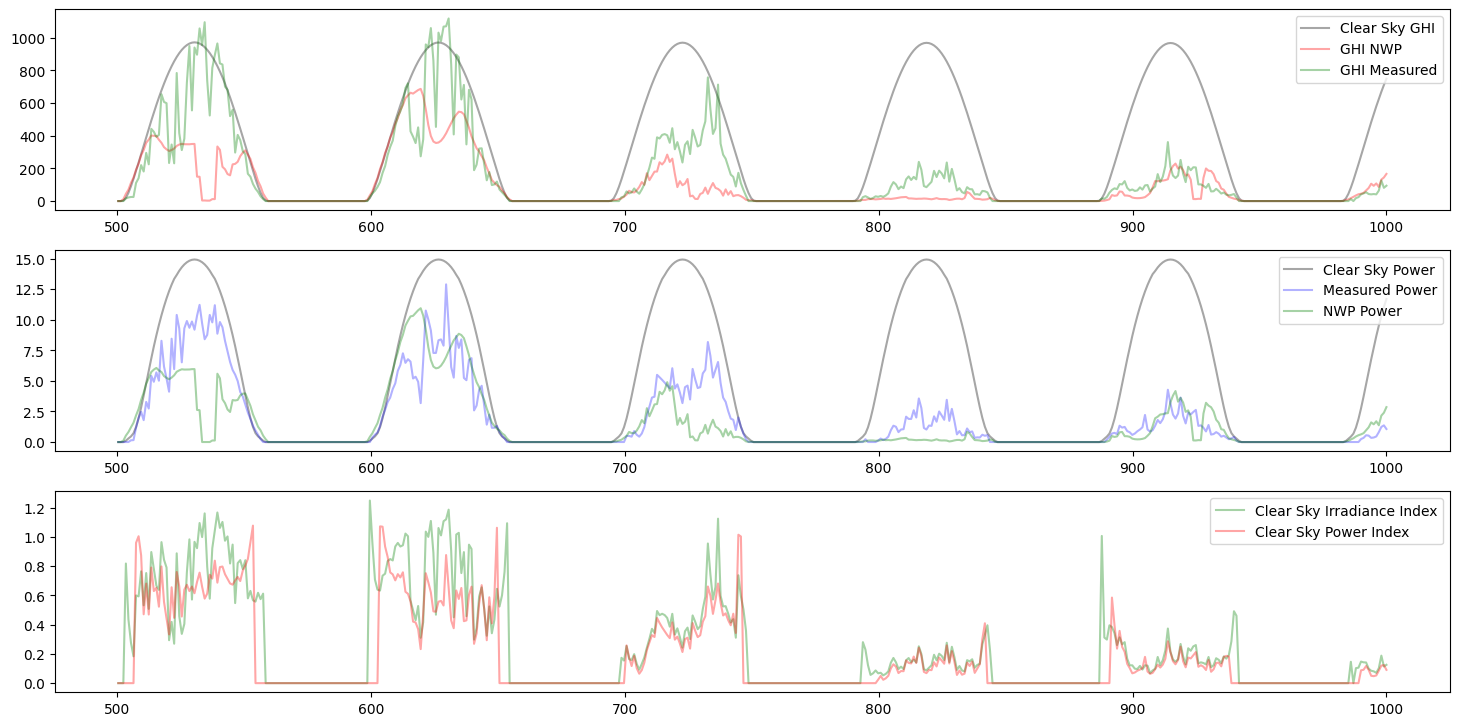

In [7]:
points = 1000
t = np.linspace(0, points, points)
start = 500

plt.figure(figsize=(18, 12))
plt.subplot(4, 1, 1)
plt.plot(t[start:points], station07_df['GHI_clr'][start:points], label='Clear Sky GHI', color='black', alpha=0.35)
plt.plot(t[start:points], station07_df['nwp_globalirrad'][start:points], label='GHI NWP', color='red', alpha=0.35)
plt.plot(t[start:points], station07_df['lmd_totalirrad'][start:points], label='GHI Measured', color='green', alpha=0.35)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t[start:points], station07_df['P_CLR'][start:points], label='Clear Sky Power', color='black', alpha=0.35)
plt.plot(t[start:points], station07_df['power'][start:points], label='Measured Power', color='blue', alpha=0.3)
plt.plot(t[start:points], station07_df['NWP_Power_MW'][start:points], label='NWP Power', color='green', alpha=0.35)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t[start:points], station07_df['K_CS'][start:points], label='Clear Sky Irradiance Index', color='green', alpha=0.35)
plt.plot(t[start:points], station07_df['K_PV'][start:points], label='Clear Sky Power Index', color='red', alpha=0.35)
plt.legend()


plt.show()

In [8]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)

    # 3. Months
    data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

    # seasons 
    data['season_sin'] = np.sin(2 * np.pi * data.index.month / 4)
    data['season_cos'] = np.cos(2 * np.pi * data.index.month / 4)
    
    
    
    return data


station07_df = prepare_features(station07_df)




In [9]:
df = station07_df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [10]:
# 1. Calculate the time difference between consecutive rows
time_diffs = df.index.to_series().diff().dropna()

# 2. Check if all differences are the same
# We use nunique() to see if there is more than 1 type of time jump
is_continuous = time_diffs.nunique() == 1

if is_continuous:
    print(f"Data is continuous. Frequency: {time_diffs.iloc[0]}")
else:
    print("Data has gaps or irregular frequencies.")
    print(f"Most common frequency: {time_diffs.mode()[0]}")

Data has gaps or irregular frequencies.
Most common frequency: 0 days 00:15:00


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
station07_df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,...,K_PV,NWP_Power_MW,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_sin,season_cos
date_time,,,,,,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,...,0.0,0.0,-0.866025,-0.500000,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,...,0.0,0.0,-0.965926,-0.258819,0.025818,-0.999667,1.224647e-16,-1.0,3.673940e-16,-1.0


----

#### Data Preparation and Dataset

In [13]:
import os
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
from typing import List


warnings.filterwarnings('ignore')



class MultiStepDataset(Dataset):
    """
    prepare data set for the model. As X is the past F features, Y is the target and P is the prediction features represents the predictions of the corresponding time step after seq_len, 
    seq_len
    Returns:
        x_past   : [seq_len, F]
        y_future : [pred_len, 1]
        x_future : [pred_len, F]
    """
    def __init__(self, X, Y, P, seq_len=96, pred_len=96): # One day back and Forward.
        self.X = X  # numpy array [T, F]
        self.y = Y  # numpy array [T, 1] (K_PV)
        self.P = P  # numpy array [T, F]
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        # past window
        x_past = self.X[i : i + self.seq_len]  # [seq_len, F]

        # future horizon
        start_fut = i + self.seq_len
        end_fut   = start_fut + self.pred_len

        y_future = self.y[start_fut : end_fut]         # [pred_len, 1]
        x_future = self.P[start_fut : end_fut]         # [pred_len, F]

        return (
            torch.tensor(x_past,   dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32),
            torch.tensor(x_future, dtype=torch.float32),
        )




def prepare_rolling_folds(
    df, input_cols, target_col, prediction_cols,
    n_splits=2, seq_len=96, pred_len=96, batch_size=32
):
    X_raw = df[input_cols].values.astype(np.float32)
    P_raw = df[prediction_cols].values.astype(np.float32)
    
    y_raw = df[target_col].values.astype(np.float32)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold = 0
    for train_index, test_index in tscv.split(X_raw):
        fold += 1
        
        # Split Data
        X_train_fold = X_raw[train_index]
        P_train_fold = P_raw[train_index]
        y_train_fold = y_raw[train_index]

        X_test_fold = X_raw[test_index]
        P_test_fold = P_raw[test_index]
        y_test_fold = y_raw[test_index]

        # Prepend Lookback for Test Set
        # We need the last 'seq_len' points from train to predict the first point of test
        X_lookback = X_train_fold[-seq_len:]
        P_lookback = P_train_fold[-seq_len:]
        y_lookback = y_train_fold[-seq_len:]

        X_test_final = np.concatenate([X_lookback, X_test_fold], axis=0)
        P_test_final = np.concatenate([P_lookback, P_test_fold], axis=0)
        y_test_final = np.concatenate([y_lookback, y_test_fold], axis=0)

        # Create Datasets
        train_dataset = MultiStepDataset(
            X_train_fold, y_train_fold, P_train_fold, seq_len=seq_len, pred_len=pred_len
        )
        test_dataset = MultiStepDataset(
            X_test_final, y_test_final, P_test_final, seq_len=seq_len, pred_len=pred_len
        )

        # Create Loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        yield train_loader, test_loader




----

## Model

In [14]:
import torch
import torch.nn as nn

# Official RevIN implementation https://github.com/ts-kim/RevIN 
"""
Reversible Instance Normalization
it removes the need for the model to learn different "rules" for Summer vs. Winter.

- In solar forecasting, a clear sunny day in winter has a much lower peak (amplitude) than a clear sunny day in summer due to the sun's angle. 
Standard models struggle because they see these as two different patterns
- RevIN normalizes each input window individually: 
    - It calculates the mean (μ) and standard deviation (σ) for just that specific window of time
    - It subtracts the mean and divides by the standard deviation.
To the model, a "Winter Sunny Day" and a "Summer Sunny Day" look almost identical (they both become a standardized curve). 
The model focuses on learning the shape (the curve of the sun, cloud interruptions) rather than the scale (magnitude).

RevIN handles Night records with zeroes elegantly because it is instance-based (local) rather than global.
- The paper describes "Affine Parameters" (γ,β) which are learnable weights in the normalization layer
    - Solar curves are not perfectly Gaussian (bell-shaped). The learnable parameters allow the model to slightly "shift" or "stretch" the normalized data to better fit the model's internal preferences.
    - 
"""

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize RevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x

------

In [15]:
class moving_avg(torch.nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x
        

class series_decomp(torch.nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean



In [16]:
from mamba_ssm import Mamba
class Model_v0(torch.nn.Module):
    def __init__(self,configs):
        super(Model, self).__init__()
        self.configs=configs
        
        self.enc_in = len(self.configs.PAST_INPUT_COLS) + self.configs.num_shadows
        # Prevents token size from expanding excessively while retaining predictive info.
        # "squeezes" the enriched information back to the original context length L so that the model's complexity does not scale with the size of the prediction window.
        self.lin1=torch.nn.Linear(2*(self.configs.seq_len+self.configs.pred_len),self.configs.seq_len)

        # Find the indices of the target columns
        self.target_indices = [
            self.configs.PAST_INPUT_COLS.index(col) 
            for col in self.configs.TARGET_COL
        ]
        
        # NOTE: What is the size affect on.
        kernel_size = self.configs.kernel_size
        self.decompsition = series_decomp(kernel_size)
        
        self.revin_layer = RevIN(self.configs.enc_in)
        self.revin_layer_enc = RevIN(self.configs.enc_in)
        
        # By combining these different views, PowerMamba achieves a 7% improvement in prediction error while using 43% fewer parameters than other Mamba-based models.
        self.lin2=torch.nn.Linear(2*(self.configs.seq_len),self.configs.n_embed)

        self.lin3=torch.nn.Linear(4*self.configs.n_embed,self.configs.pred_len)
        
        self.dropout1=torch.nn.Dropout(self.configs.dropout)
        self.dropout2=torch.nn.Dropout(self.configs.dropout)

        # The Temporal Expert: captures intra-series dependencies (patterns within a single time series)
        self.mamba1 = Mamba(d_model=self.configs.n_embed,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)
        # The Feature Expert: captures inter-series relationships (how different features like Temperature and Global Irradiation interact with each other at a specific moment)
        self.mamba2 = Mamba(d_model=self.configs.enc_in,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)

    def forward(self, x, x_f, y):
        # Assumption x is the input historical features (B, L, C) with Length of L. 
        # x_f is the prediction features (B, H, C) H is horizon or prediction length, C is the number of features
        # y is the target (B, H, 1)
        # All x, x_f, y are of shape (batch_size, seq_len{L,H}, feature_size)

        
        batch_size = x.size(0)

        # 1. Initialize the Expanded Tensor
        # Width = Original Past Cols + Shadow Cols
        x_pred = torch.zeros(batch_size, self.configs.seq_len + self.configs.pred_len, self.configs.enc_in).to(x.device)


        # 2. Fill the "Past" section with historical data x
        # We fill the first N columns (where N = len(PAST_INPUT_COLS))
        num_past_feats = len(self.configs.PAST_INPUT_COLS)
        x_pred[:, :self.configs.seq_len, :num_past_feats] = x

        # 3. Dynamic Shadow Feature Generation
        # We start filling shadow columns *after* the original features
        shadow_col_start_idx = num_past_feats

        for i, feature_name in enumerate(self.configs.common_features):
            # A. Find indices dynamically
            past_idx = self.configs.PAST_INPUT_COLS.index(feature_name)
            fut_idx  = self.configs.FUTURE_INPUT_COLS.index(feature_name)
            
            # B. Extract the forecast from x_f
            # shape: [Batch, H]
            forecast_values = x_f[:, :, fut_idx]
            
            # C. ALIGNMENT: Fill the future hole of the *original* column
            # This ensures the model sees the forecast as a continuation of the past
            x_pred[:, self.configs.seq_len:, past_idx] = forecast_values
            
            # D. SHIFTING: Create the Shadow Column
            # Shadow column index = Start of shadows + current iteration
            current_shadow_idx = shadow_col_start_idx + i
            # FIX: Resize forecast_values to match seq_len if they differ
            if self.configs.seq_len != self.configs.pred_len:
                # 1. Add dimension for interpolation: [Batch, 1, H]
                f_val_reshaped = forecast_values.unsqueeze(1)
                
                # 2. Interpolate to Length L: [Batch, 1, L]
                f_val_resized = torch.nn.functional.interpolate(
                    f_val_reshaped, 
                    size=self.configs.seq_len, 
                    mode='linear', 
                    align_corners=False
                )
                
                # 3. Remove extra dimension: [Batch, L]
                shadow_values = f_val_resized.squeeze(1)
            else:
                shadow_values = forecast_values
            
            # Shift Logic: The future forecast is copied into the PAST rows of the shadow column.
            # D. Fill the Shadow Column (Now safe even if lengths differ)
            x_pred[:, :self.configs.seq_len, current_shadow_idx] = shadow_values
            
            # Fill the future part of the shadow column (Use original forecast length)
            x_pred[:, self.configs.seq_len:, current_shadow_idx] = forecast_values

        # 4. Standard PowerMamba Processing
        x = x_pred # x is now size [Batch, L+H, enc_in]
        
        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)
        
        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x) # Squeeze back to L
        x = torch.permute(x, (0, 2, 1))
        
        x = self.revin_layer_enc(x, 'denorm')
        
        
        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e= torch.cat([seasonal_init, trend_init], dim=1)

        x_e = torch.permute(x_e, (0,2,1))
        x_e = self.lin2(x_e)
        
        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0,2,1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0,2,1))
        

        x = torch.cat([x_im, x_m, x_m+x_im, x_e], dim=2)
        
        # Project to Prediction Horizon [Batch, enc_in, pred_len]
        x = self.lin3(x)
        
        # Permute to [Batch, pred_len, enc_in]
        x = torch.permute(x, (0,2,1))
        # Denormalize ALL features first (RevIN expects enc_in channels)
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices] # Shape becomes [32, 3, 1]

        return x



class Model_v01(torch.nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.configs = configs
        
        # --- Dimensions ---
        self.num_past_feats = len(self.configs.PAST_INPUT_COLS)
        self.num_shadows = len(self.configs.common_features)
        self.enc_in = self.num_past_feats + self.num_shadows
        
        # --- Pre-calculate Indices for Vectorization ---
        # We find the indices of common features in FUTURE and PAST lists once
        # to avoid doing it inside the forward loop.
        
        # 1. Where are the common features in x_f (Future)?
        self.fut_indices = torch.tensor(
            [self.configs.FUTURE_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )
        
        # 2. Where should they go in x_pred (The "Past" slots)?
        self.past_target_indices = torch.tensor(
            [self.configs.PAST_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )

        # 3. Where do the Shadow Columns start?
        self.shadow_start_idx = self.num_past_feats
        
        # --- Layers ---
        self.lin1 = torch.nn.Linear(2*(self.configs.seq_len + self.configs.pred_len), self.configs.seq_len)
        self.target_indices = [self.configs.PAST_INPUT_COLS.index(col) for col in self.configs.TARGET_COL]
        
        self.decompsition = series_decomp(self.configs.kernel_size)
        self.revin_layer = RevIN(self.configs.enc_in)
        self.revin_layer_enc = RevIN(self.configs.enc_in)
        
        self.lin2 = torch.nn.Linear(2*self.configs.seq_len, self.configs.n_embed)
        self.lin3 = torch.nn.Linear(4*self.configs.n_embed, self.configs.pred_len)
        
        self.dropout1 = torch.nn.Dropout(self.configs.dropout)
        self.dropout2 = torch.nn.Dropout(self.configs.dropout)

        self.mamba1 = Mamba(
            d_model=self.configs.n_embed, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
        self.mamba2 = Mamba(
            d_model=self.configs.enc_in, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )

    def forward(self, x, x_f, y):
        batch_size = x.size(0)
        device = x.device

        # Ensure indices are on the correct device (do this once or check casually)
        if self.fut_indices.device != device:
            self.fut_indices = self.fut_indices.to(device)
            self.past_target_indices = self.past_target_indices.to(device)

        # ============================================================
        # 1. Vectorized Input Construction
        # ============================================================
        # L is the length of the past data, H is the length of the future data
        # Enc_In is the number of features
        # Create the blank canvas: [Batch, L + H, Enc_In]
        total_len = self.configs.seq_len + self.configs.pred_len
        x_pred = torch.zeros(batch_size, total_len, self.enc_in, device=device)

        # A. Fill Original Past Data [Batch, L, Past_Feats]
        
        x_pred[:, :self.configs.seq_len, :self.num_past_feats] = x

        # B. Bulk Extract Forecasts for Shadows
        # shape: [Batch, H, Num_Shadows] ....  shadow_forecasts: [B, H, S]
        shadow_forecasts = torch.index_select(x_f, 2, self.fut_indices)

        # C. Fill "Future Hole" of Original Columns (Alignment)
        # We put the forecasts into the future part of the original columns
        # Note: We can't easily vector-assign to non-contiguous indices, so we loop over columns
        # OR we can assume contiguous. For safety, a small loop here is fine, OR use scatter.
        # Given the complexity, let's do the Shadow Shift vectorization first, which is the heavy part.
        
        # --- Vectorized Shadow Generation ---
        

        # --- Option A: Learnable projection instead of interpolation ---
        # Map [B, H, S] -> [B, L, S] using a learned linear map along time.
        if self.shadow_time_proj is not None:
            # [B, H, S] -> [B, S, H]
            sf = shadow_forecasts.permute(0, 2, 1)
            # apply Linear(H -> L) on last dim: [B, S, H] -> [B, S, L]
            sf_L = self.shadow_time_proj(sf)
            # [B, S, L] -> [B, L, S]
            shadow_values_past = sf_L.permute(0, 2, 1)
        else:
            shadow_values_past = shadow_forecasts  # [B, L, S] when L == H

        # # 1. Resize Forecasts to match Past Length (L)
        # if self.configs.seq_len != self.configs.pred_len:
        #     # Permute to [Batch, Channels, Time] for interpolate
        #     sf_perm = shadow_forecasts.permute(0, 2, 1) 
            

        #     # Bug ...
        #     sf_resized = torch.nn.functional.interpolate(
        #         sf_perm, 
        #         size=self.configs.seq_len, 
        #         mode='linear', 
        #         align_corners=False
        #     )
        #     # Permute back: [Batch, L, Num_Shadows]
        #     shadow_values_past = sf_resized.permute(0, 2, 1)
        # else:
        #     shadow_values_past = shadow_forecasts

        # 2. Fill Shadow Columns (The "Past" part)
        # Target indices: from num_past_feats to end
        x_pred[:, :self.configs.seq_len, self.shadow_start_idx:] = shadow_values_past

        # 3. Fill Shadow Columns (The "Future" part)
        x_pred[:, self.configs.seq_len:, self.shadow_start_idx:] = shadow_forecasts
        
        # 4. Fill Original Columns Future Part (Alignment)
        # This fills the "Hole" in the non-shadow columns
        # We use a loop here because 'past_target_indices' might be scattered (0, 2, 5...)
        # But this loop is over FEATURES (e.g., 3 or 4), not TIME, so it is fast.
        for i, past_idx in enumerate(self.past_target_indices):
            x_pred[:, self.configs.seq_len:, past_idx] = shadow_forecasts[:, :, i]

        # ============================================================
        # 2. Standard PowerMamba Processing 
        # ============================================================
        x = x_pred 
        
        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)
        
        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x) 

        
        x = torch.permute(x, (0, 2, 1))
        
        x = self.revin_layer_enc(x, 'denorm')
        
        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e= torch.cat([seasonal_init, trend_init], dim=1)

        x_e = torch.permute(x_e, (0,2,1))
        x_e = self.lin2(x_e)
        
        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0,2,1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0,2,1))
        
        x = torch.cat([x_im, x_m, x_m+x_im, x_e], dim=2)
        
        x = self.lin3(x)
        x = torch.permute(x, (0,2,1))
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices] 

        return x


import torch
import torch.nn as nn

class Model_v04(torch.nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.configs = configs

        # --- Dimensions ---
        self.num_past_feats = len(self.configs.PAST_INPUT_COLS)
        self.num_shadows   = len(self.configs.common_features)
        self.enc_in        = self.num_past_feats + self.num_shadows

        # --- Pre-calculate Indices ---
        self.fut_indices = torch.tensor(
            [self.configs.FUTURE_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )
        self.past_target_indices = torch.tensor(
            [self.configs.PAST_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )
        self.shadow_start_idx = self.num_past_feats

        # --- NEW: Learnable projection from horizon (H) -> context length (L) ---
        # Applies per shadow-channel, along the time dimension.
        # Input:  [B, S, H]  -> Output: [B, S, L]
        # (We still bypass this if L == H.)
        if self.configs.seq_len != self.configs.pred_len:
            self.shadow_time_proj = nn.Linear(self.configs.pred_len, self.configs.seq_len, bias=True)
        else:
            self.shadow_time_proj = None

        # --- Layers (unchanged) ---
        self.lin1 = torch.nn.Linear(2 * (self.configs.seq_len + self.configs.pred_len), self.configs.seq_len)
        self.target_indices = [self.configs.PAST_INPUT_COLS.index(col) for col in self.configs.TARGET_COL]

        self.decompsition = series_decomp(self.configs.kernel_size)
        self.revin_layer = RevIN(self.configs.enc_in)
        self.revin_layer_enc = RevIN(self.configs.enc_in)

        self.lin2 = torch.nn.Linear(2 * self.configs.seq_len, self.configs.n_embed)
        self.lin3 = torch.nn.Linear(4 * self.configs.n_embed, self.configs.pred_len)

        self.dropout1 = torch.nn.Dropout(self.configs.dropout)
        self.dropout2 = torch.nn.Dropout(self.configs.dropout)

        self.mamba1 = Mamba(
            d_model=self.configs.n_embed, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
        self.mamba2 = Mamba(
            d_model=self.configs.enc_in, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )

    def forward(self, x, x_f, y):
        batch_size = x.size(0)
        device = x.device

        # Ensure indices are on the correct device
        if self.fut_indices.device != device:
            self.fut_indices = self.fut_indices.to(device)
            self.past_target_indices = self.past_target_indices.to(device)

        # ============================================================
        # 1. Vectorized Input Construction
        # ============================================================
        total_len = self.configs.seq_len + self.configs.pred_len
        x_pred = torch.zeros(batch_size, total_len, self.enc_in, device=device)

        # A. Fill Original Past Data
        x_pred[:, :self.configs.seq_len, :self.num_past_feats] = x

        # B. Extract horizon forecasts for shadow features
        # shadow_forecasts: [B, H, S]
        shadow_forecasts = torch.index_select(x_f, 2, self.fut_indices)

        # --- Option A: Learnable projection instead of interpolation ---
        # Map [B, H, S] -> [B, L, S] using a learned linear map along time.
        if self.shadow_time_proj is not None:
            # [B, H, S] -> [B, S, H]
            sf = shadow_forecasts.permute(0, 2, 1)
            # apply Linear(H -> L) on last dim: [B, S, H] -> [B, S, L]
            sf_L = self.shadow_time_proj(sf)
            # [B, S, L] -> [B, L, S]
            shadow_values_past = sf_L.permute(0, 2, 1)
        else:
            shadow_values_past = shadow_forecasts  # [B, L, S] when L == H

        # 2. Fill Shadow Columns (Past part)
        x_pred[:, :self.configs.seq_len, self.shadow_start_idx:] = shadow_values_past

        # 3. Fill Shadow Columns (Future part)
        x_pred[:, self.configs.seq_len:, self.shadow_start_idx:] = shadow_forecasts

        # 4. Fill Original Columns Future Part (Alignment)
        for i, past_idx in enumerate(self.past_target_indices):
            x_pred[:, self.configs.seq_len:, past_idx] = shadow_forecasts[:, :, i]

        # ============================================================
        # 2. Standard PowerMamba Processing (Unchanged)
        # ============================================================
        x = x_pred

        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)

        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x)

        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer_enc(x, 'denorm')

        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e = torch.cat([seasonal_init, trend_init], dim=1)
        x_e = torch.permute(x_e, (0, 2, 1))
        x_e = self.lin2(x_e)

        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0, 2, 1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0, 2, 1))

        x = torch.cat([x_im, x_m, x_m + x_im, x_e], dim=2)

        x = self.lin3(x)
        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices]
        return x


import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt

class Model(torch.nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.configs = configs

        # --- Dimensions ---
        self.num_past_feats = len(self.configs.PAST_INPUT_COLS)
        self.num_shadows   = len(self.configs.common_features)
        self.enc_in        = self.num_past_feats + self.num_shadows

        # --- Pre-calculate Indices ---
        self.fut_indices = torch.tensor(
            [self.configs.FUTURE_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )
        self.past_target_indices = torch.tensor(
            [self.configs.PAST_INPUT_COLS.index(f) for f in self.configs.common_features],
            dtype=torch.long
        )
        self.shadow_start_idx = self.num_past_feats

        # --- Learnable projection from horizon (H) -> context length (L) ---
        if self.configs.seq_len != self.configs.pred_len:
            self.shadow_time_proj = nn.Linear(self.configs.pred_len, self.configs.seq_len, bias=True)
        else:
            self.shadow_time_proj = None

        # ============================================================
        # Wavelet details on residual
        # ============================================================
        self.use_wavelet = getattr(self.configs, "use_wavelet", True)
        self.wavelet_name = getattr(self.configs, "wavelet_name", "db4")

        if self.use_wavelet:
            w = pywt.Wavelet(self.wavelet_name)
            # high-pass decomposition filter
            filt = w.dec_hi if hasattr(w, "dec_hi") else w.dec_h
            dec_hi = torch.tensor(filt, dtype=torch.float32).flip(0)  # conv1d correlation
            self.register_buffer("wavelet_dec_hi", dec_hi)
        else:
            self.wavelet_dec_hi = None

        # --- Layers ---
        # NOTE: concatenation factor is 3 if wavelet enabled, else 2
        cat_factor_stage1 = 3 if self.use_wavelet else 2
        cat_factor_stage2 = 3 if self.use_wavelet else 2

        self.lin1 = nn.Linear(
            cat_factor_stage1 * (self.configs.seq_len + self.configs.pred_len),
            self.configs.seq_len
        )

        self.target_indices = [self.configs.PAST_INPUT_COLS.index(col) for col in self.configs.TARGET_COL]

        self.decompsition = series_decomp(self.configs.kernel_size)
        self.revin_layer = RevIN(self.enc_in)
        self.revin_layer_enc = RevIN(self.enc_in)

        self.lin2 = nn.Linear(cat_factor_stage2 * self.configs.seq_len, self.configs.n_embed)
        self.lin3 = nn.Linear(4 * self.configs.n_embed, self.configs.pred_len)

        self.dropout1 = nn.Dropout(self.configs.dropout)
        self.dropout2 = nn.Dropout(self.configs.dropout)

        self.mamba1 = Mamba(
            d_model=self.configs.n_embed, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )
        self.mamba2 = Mamba(
            d_model=self.enc_in, d_state=self.configs.d_state,
            d_conv=self.configs.dconv, expand=self.configs.e_fact
        )

    def _wavelet_details(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute wavelet detail coefficients via grouped conv1d.
        x: [B, T, C] -> returns [B, T, C]
        """
        # If disabled, return zeros with same shape (keeps code simple)
        if not self.use_wavelet:
            return torch.zeros_like(x)

        B, T, C = x.shape
        # self.wavelet_dec_hi is a buffer already on the correct device
        dec_hi = self.wavelet_dec_hi  # [K]
        K = dec_hi.numel()

        # conv1d input: [B, C, T]
        x_t = x.permute(0, 2, 1)

        # weight: [C, 1, K] for grouped conv
        w = dec_hi.view(1, 1, K).repeat(C, 1, 1)

        pad = K // 2
        details = F.conv1d(x_t, w, padding=pad, groups=C)  # [B, C, T'] depending on padding

        # length correction to exactly T
        if details.shape[-1] > T:
            details = details[:, :, :T]
        elif details.shape[-1] < T:
            details = F.pad(details, (0, T - details.shape[-1]))

        return details.permute(0, 2, 1)  # [B, T, C]

    def forward(self, x, x_f, y):
        batch_size = x.size(0)
        device = x.device

        # Ensure indices are on the correct device
        if self.fut_indices.device != device:
            self.fut_indices = self.fut_indices.to(device)
            self.past_target_indices = self.past_target_indices.to(device)

        # ============================================================
        # 1. Vectorized Input Construction
        # ============================================================
        total_len = self.configs.seq_len + self.configs.pred_len
        x_pred = torch.zeros(batch_size, total_len, self.enc_in, device=device)

        # A. Fill Original Past Data
        x_pred[:, :self.configs.seq_len, :self.num_past_feats] = x

        # B. Extract horizon forecasts for shadow features
        # shadow_forecasts: [B, H, S]
        shadow_forecasts = torch.index_select(x_f, 2, self.fut_indices)

        # Option A: Learnable projection H -> L for "past shadow values"
        if self.shadow_time_proj is not None:
            sf = shadow_forecasts.permute(0, 2, 1)  # [B, S, H]
            sf_L = self.shadow_time_proj(sf)         # [B, S, L]
            shadow_values_past = sf_L.permute(0, 2, 1)  # [B, L, S]
        else:
            shadow_values_past = shadow_forecasts  # [B, L, S] only when L == H

        # 2. Fill Shadow Columns (Past part)
        x_pred[:, :self.configs.seq_len, self.shadow_start_idx:] = shadow_values_past

        # 3. Fill Shadow Columns (Future part)
        x_pred[:, self.configs.seq_len:, self.shadow_start_idx:] = shadow_forecasts

        # 4. Fill Original Columns Future Part (Alignment)
        for i, past_idx in enumerate(self.past_target_indices):
            x_pred[:, self.configs.seq_len:, past_idx] = shadow_forecasts[:, :, i]

        # ============================================================
        # 2. Standard PowerMamba Processing + Wavelet Residual Details
        # ============================================================
        x = x_pred

        # ---- Stage 1 (length = seq_len + pred_len) ----
        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        if self.use_wavelet:
            wavelet_init = self._wavelet_details(seasonal_init)
            x = torch.cat([seasonal_init, trend_init, wavelet_init], dim=1)
        else:
            x = torch.cat([seasonal_init, trend_init], dim=1)

        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x)
        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer_enc(x, 'denorm')

        # ---- Stage 2 (length = seq_len) ----
        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        if self.use_wavelet:
            wavelet_init2 = self._wavelet_details(seasonal_init)
            x_e = torch.cat([seasonal_init, trend_init, wavelet_init2], dim=1)
        else:
            x_e = torch.cat([seasonal_init, trend_init], dim=1)

        x_e = torch.permute(x_e, (0, 2, 1))
        x_e = self.lin2(x_e)

        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0, 2, 1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0, 2, 1))

        x = torch.cat([x_im, x_m, x_m + x_im, x_e], dim=2)

        x = self.lin3(x)
        x = torch.permute(x, (0, 2, 1))
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices]
        return x




In [17]:
def train_one_epoch(model, loader, optimizer, criterion, teacher_forcing_ratio):
    model.train()
    total_loss = 0.0


    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        preds = model(x_past, x_future, y_future)

        loss = criterion(preds, y_future)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, None)

            loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    # Flatten for global metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae



In [18]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

        
def run_rolling_cv(df, configs):
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = Model(configs).to(device)
        criterion = nn.MSELoss().to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-3
        )

        for epoch in range(configs.epochs):
            # linear decay of teacher forcing
            tf_ratio = max(0.0, 0.5 - epoch / (configs.epochs * 0.8))

            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, tf_ratio
            )
            val_loss, val_rmse, val_mae = evaluate_fold(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | TF={tf_ratio:.2f} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history




In [19]:
df = station07_df.copy()

In [20]:
df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV', 'NWP_Power_MW', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'season_sin', 'season_cos'],
      dtype='object')

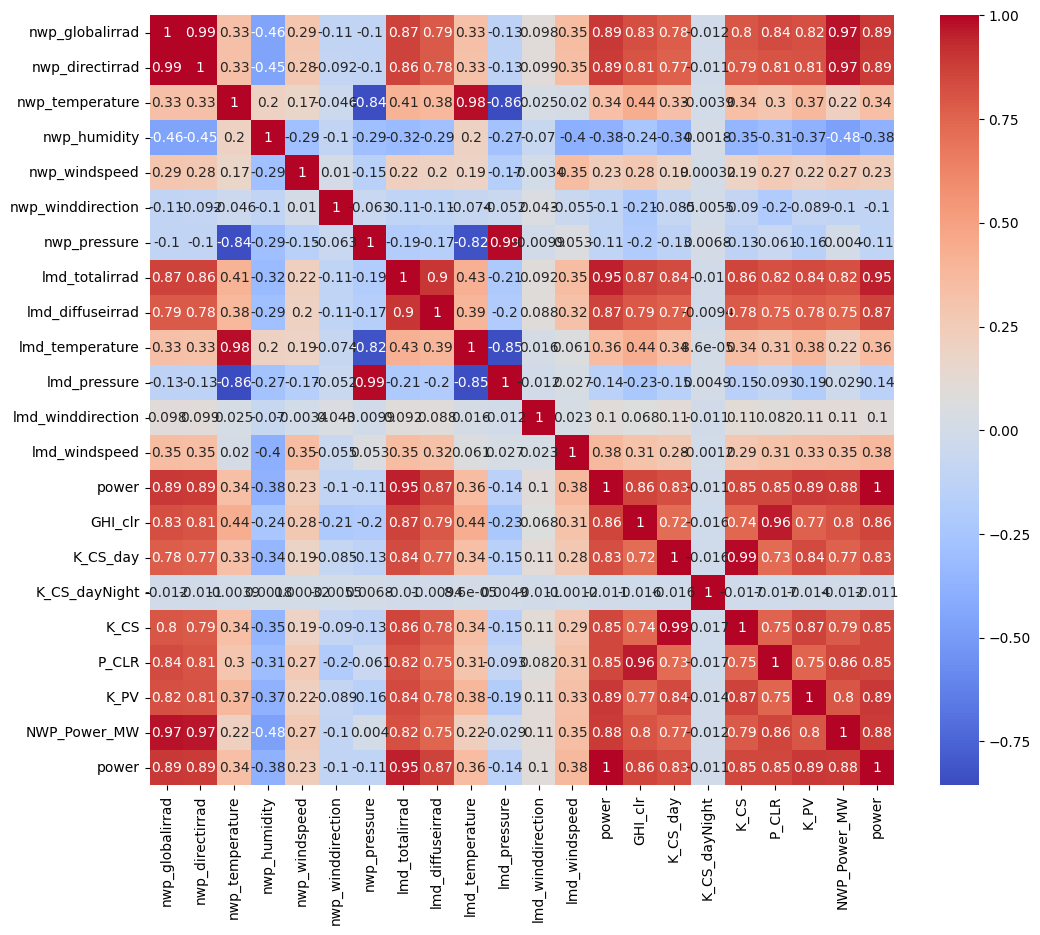

In [21]:
# correlation between features 
# heat map of features
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df[['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV', 'NWP_Power_MW', 'power']].corr(), annot=True, cmap='coolwarm')
plt.show()


In [22]:
df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV', 'NWP_Power_MW', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'season_sin', 'season_cos'],
      dtype='object')

In [23]:
class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 288        # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'K_PV',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'power']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad']
        self.TARGET_COL = ['power']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 128     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 2 
        self.batch_size = 128
        self.epochs = 50
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()


=== Training Fold 1/2 ===
Epoch 005 | TF=0.40 | Train=2.2124 | Val=2.3827 | RMSE=1.5486 | MAE=0.9237
Epoch 010 | TF=0.28 | Train=1.7730 | Val=2.4381 | RMSE=1.5591 | MAE=0.9171
Epoch 015 | TF=0.15 | Train=1.5613 | Val=2.4933 | RMSE=1.5767 | MAE=0.9252
Epoch 020 | TF=0.03 | Train=1.2988 | Val=2.6627 | RMSE=1.6378 | MAE=0.9680
Epoch 025 | TF=0.00 | Train=1.1412 | Val=2.8529 | RMSE=1.6957 | MAE=0.9963
Epoch 030 | TF=0.00 | Train=1.1030 | Val=2.7573 | RMSE=1.6644 | MAE=1.0058
Epoch 035 | TF=0.00 | Train=1.0719 | Val=2.9934 | RMSE=1.7317 | MAE=1.0519
Epoch 040 | TF=0.00 | Train=0.9533 | Val=2.9050 | RMSE=1.7070 | MAE=0.9979
Epoch 045 | TF=0.00 | Train=0.9288 | Val=2.9776 | RMSE=1.7254 | MAE=1.0236
Epoch 050 | TF=0.00 | Train=0.8867 | Val=3.0231 | RMSE=1.7378 | MAE=1.0182
--> Fold 1 Finished: RMSE=1.7378, MAE=1.0182


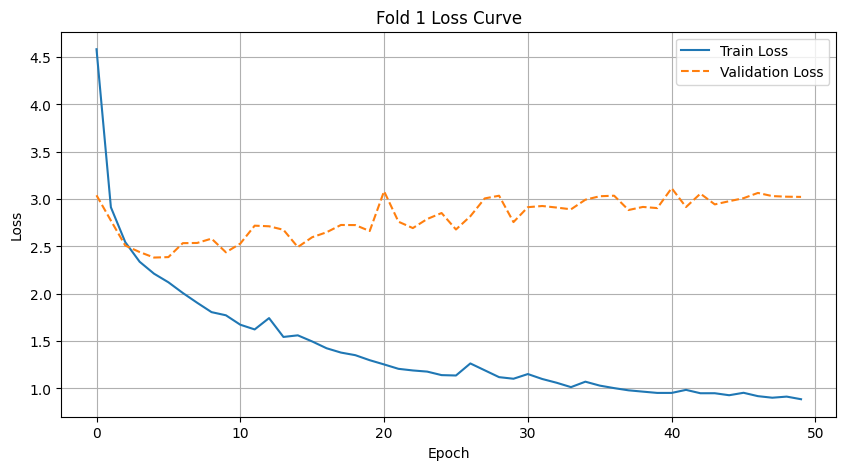


=== Training Fold 2/2 ===
Epoch 005 | TF=0.40 | Train=1.9314 | Val=4.1394 | RMSE=2.0278 | MAE=1.1957
Epoch 010 | TF=0.28 | Train=1.6788 | Val=4.1807 | RMSE=2.0417 | MAE=1.1972
Epoch 015 | TF=0.15 | Train=1.4443 | Val=4.2325 | RMSE=2.0543 | MAE=1.2459
Epoch 020 | TF=0.03 | Train=1.2852 | Val=4.0357 | RMSE=2.0058 | MAE=1.2157
Epoch 025 | TF=0.00 | Train=1.1657 | Val=4.6234 | RMSE=2.1450 | MAE=1.2990
Epoch 030 | TF=0.00 | Train=1.0905 | Val=4.4565 | RMSE=2.1015 | MAE=1.2505
Epoch 035 | TF=0.00 | Train=1.0254 | Val=4.5809 | RMSE=2.1301 | MAE=1.2958
Epoch 040 | TF=0.00 | Train=0.9929 | Val=4.7360 | RMSE=2.1708 | MAE=1.2957
Epoch 045 | TF=0.00 | Train=0.9541 | Val=5.0661 | RMSE=2.2425 | MAE=1.3023
Epoch 050 | TF=0.00 | Train=0.9167 | Val=5.3928 | RMSE=2.3151 | MAE=1.3592
--> Fold 2 Finished: RMSE=2.3151, MAE=1.3592


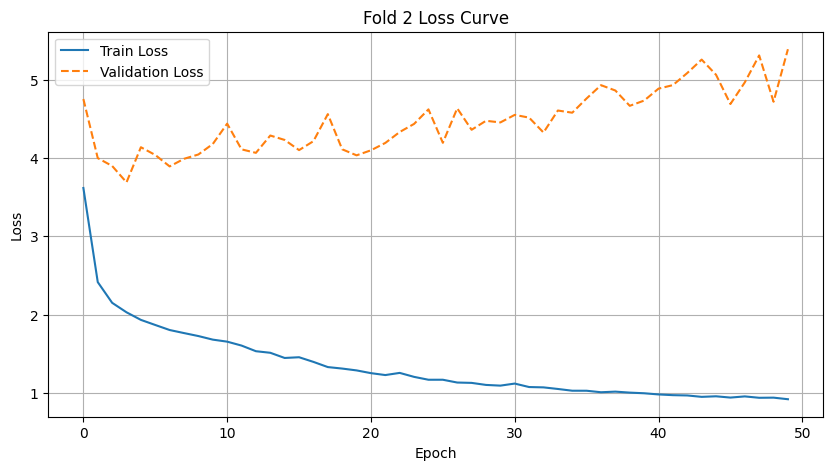


=== Final Cross-Validation Results ===
Average RMSE: 2.0264


In [25]:


results01, history01 = run_rolling_cv(df, configs)



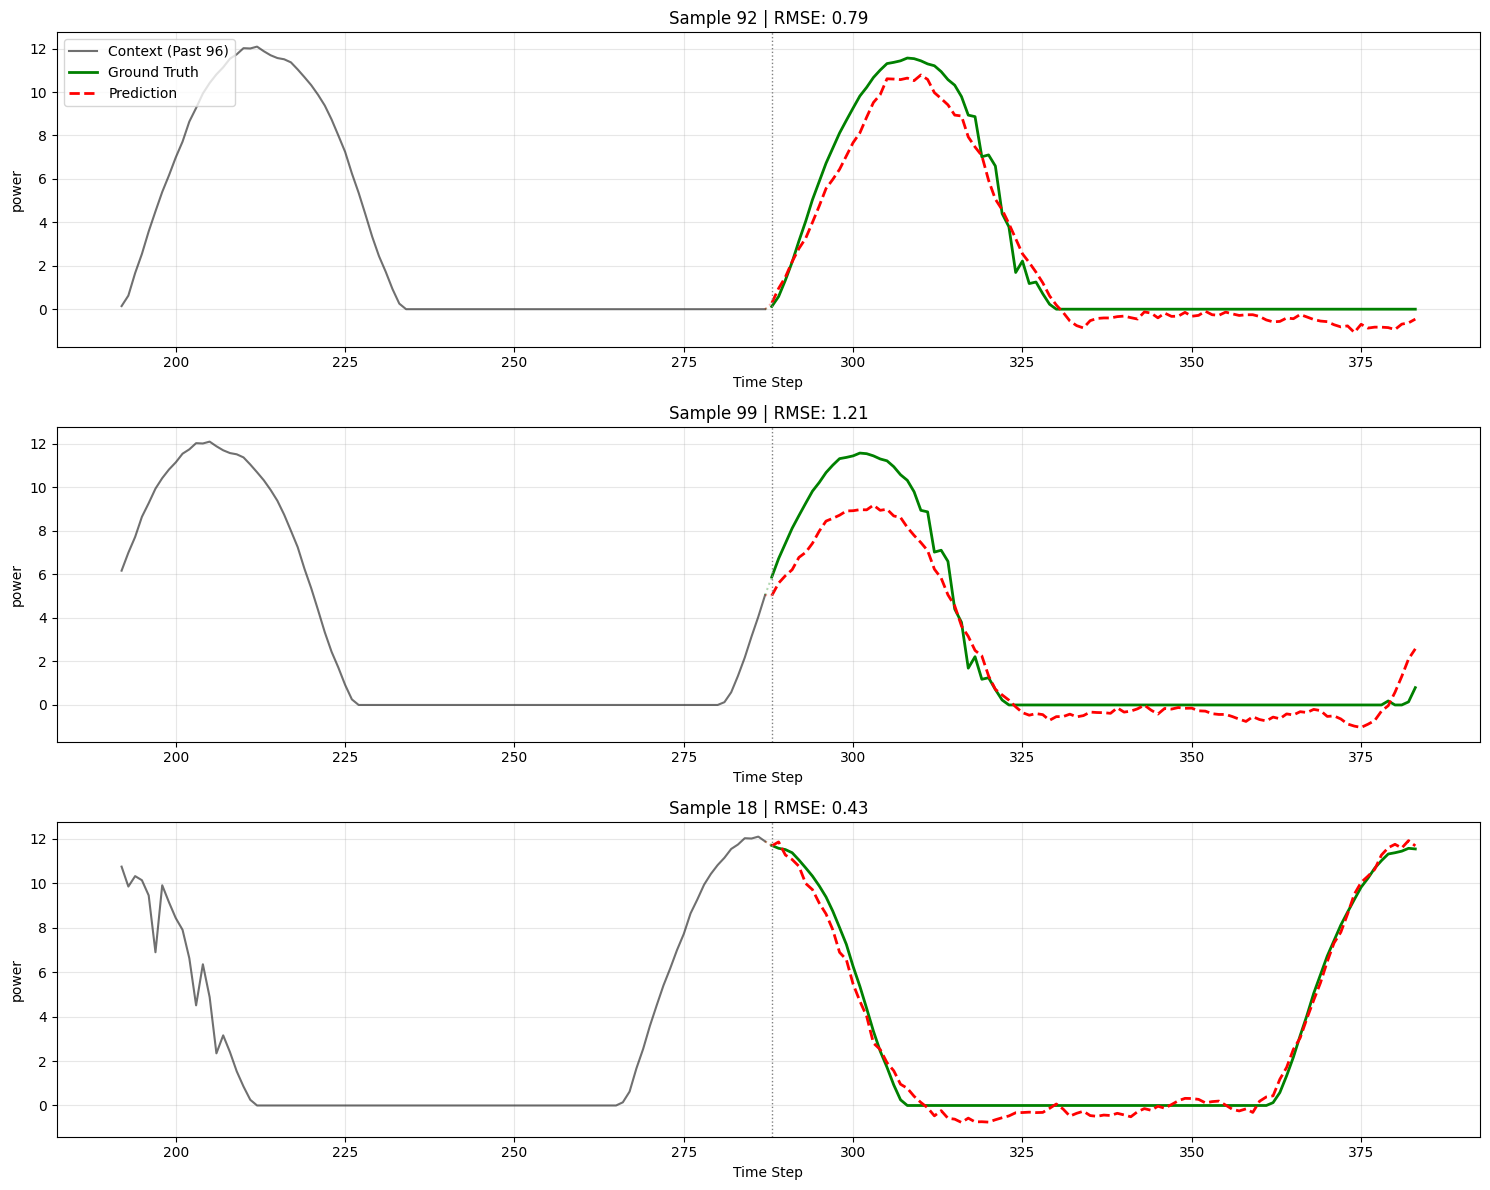

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_predictions(results, configs, fold_idx=0, num_samples=3, context_len=96):
    """
    Visualizes the model's behavior focusing on the transition from past to future.
    
    Args:
        results: The list returned by run_rolling_cv
        configs: Your MambaModelConfigs object
        fold_idx: Which fold to visualize (0 for the first fold)
        num_samples: How many random examples to show
        context_len: How many steps of the 'Past' to show (default 96)
    """
    # 1. Retrieve the correct fold data
    fold_data = results[fold_idx]
    model = fold_data['model']
    test_loader = fold_data['test_loader']
    device = configs.device
    
    # 2. Get a single batch from the test loader
    batch = next(iter(test_loader))
    x_past, y_future, x_future = batch
    
    # Move to device for inference
    x_past   = x_past.to(device)
    x_future = x_future.to(device)
    y_future = y_future.to(device)
    
    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        preds = model(x_past, x_future, None) 
        
    # 4. Move back to CPU for plotting
    x_past   = x_past.cpu().numpy()
    y_future = y_future.cpu().numpy()
    preds    = preds.cpu().numpy()
    
    # 5. Identify the Index of the Target Column
    target_idx = configs.PAST_INPUT_COLS.index(configs.TARGET_COL[0])
    
    # 6. Pick Random Indices
    total_batch_size = x_past.shape[0]
    n_plot = min(num_samples, total_batch_size)
    sample_indices = np.random.choice(range(total_batch_size), size=n_plot, replace=False)
    
    # 7. Plotting Loop
    plt.figure(figsize=(15, 4 * n_plot)) # Slightly taller for better detail
    
    # Dimensions for time axes
    seq_len = x_past.shape[1]
    pred_len = y_future.shape[1]
    
    # Calculate start index for the past (ensure we don't go negative)
    past_start_idx = max(0, seq_len - context_len)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(n_plot, 1, i+1)
        
        # --- A. Extract Data (Sliced) ---
        # Get only the last 'context_len' steps of history
        past_history = x_past[idx, past_start_idx:, target_idx] 
        true_future  = y_future[idx, :, 0]
        pred_future  = preds[idx, :, 0]
        
        # --- B. Create Time Axes ---
        # We keep the X-axis continuous relative to the total sequence
        t_past = np.arange(past_start_idx, seq_len)
        t_future = np.arange(seq_len, seq_len + pred_len)
        
        # --- C. Plot ---
        # Plot Past
        plt.plot(t_past, past_history, label='Context (Past 96)', color='#333333', alpha=0.7)
        
        # Plot Future (Ground Truth)
        plt.plot(t_future, true_future, label='Ground Truth', color='green', linewidth=2)
        
        # Plot Prediction
        plt.plot(t_future, pred_future, label='Prediction', color='red', linestyle='--', linewidth=2)
        
        # --- D. Styling & Connectors ---
        # Draw a vertical line at "Present Time"
        plt.axvline(x=seq_len, color='gray', linestyle=':', linewidth=1)
        
        # Optional: Connect the last past point to the first future point for visual continuity
        # This helps see if there is a "jump" at the prediction start
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], true_future[0]], 
                 color='green', linestyle=':', alpha=0.3)
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], pred_future[0]], 
                 color='red', linestyle=':', alpha=0.3)

        # Metrics
        sample_rmse = np.sqrt(np.mean((true_future - pred_future)**2))
        plt.title(f"Sample {idx} | RMSE: {sample_rmse:.2f}")
        plt.ylabel(configs.TARGET_COL[0])
        plt.xlabel("Time Step")
        plt.grid(True, alpha=0.3)
        
        if i == 0:
            plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

visualize_predictions(results01, configs, fold_idx=0, num_samples=3, context_len=96)

In [33]:
def get_smart_persistence_pred(df, t_idx, pred_len):
    """
    Returns the Smart Persistence prediction for a specific time step.
    
    Args:
        df: DataFrame containing 'K_PV' and 'P_CLR'
        t_idx: Integer index of the "Current Time" (last known point)
        pred_len: How far into the future to predict
        
    Returns:
        np.array: Prediction of shape [pred_len]
    """
    # 1. Get the current "Cloudiness" (K_PV at time t)
    # We use the average of the last few steps to be robust, or just the last one.
    current_k_pv = df['K_PV'].iloc[t_idx]
    
    # 2. Get the FUTURE Clear Sky Power (P_CLR at t+1 ... t+pred_len)
    future_p_clr = df['P_CLR'].iloc[t_idx+1 : t_idx+1+pred_len].values
    
    # 3. Calculate Prediction
    # "The clouds stay the same, but the sun moves"
    preds = current_k_pv * future_p_clr
    
    return preds

In [34]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from numpy.lib.stride_tricks import sliding_window_view

# --- 1. Helper: Create Windows for Baselines ---
def get_windows(data, seq_len, pred_len):
    # Shape: [N, pred_len]
    w = sliding_window_view(data, window_shape=pred_len)
    # Align with dataset (skip the history part)
    return w[seq_len:]

# --- 2. The Benchmark Function ---
def benchmark_results(results, df, configs):
    print(f"{'Fold':<5} | {'Model':<10} | {'MAE (MW)':<10} | {'RMSE (MW)':<10}")
    print("-" * 50)

    # 1. Re-generate the Split Indices to match the folds
    tscv = TimeSeriesSplit(n_splits=configs.n_splits)
    splits = list(tscv.split(df))
    
    # 2. Iterate through your existing results
    for i, res in enumerate(results):
        fold_num = res['fold']
        model = res['model']
        test_loader = res['test_loader']
        
        # Get the EXACT data slice used for this fold
        train_idx, test_idx = splits[i]
        
        # We need the 'Lookback' part of the data to align baselines
        # (The dataset used X_train[-seq_len:] + X_test)
        lookback_idx = train_idx[-configs.seq_len:]
        full_test_idx = np.concatenate([lookback_idx, test_idx])
        
        # --- A. Prepare Baselines (NWP & Clear Sky) ---
        # Extract from DF
        nwp_slice = df['NWP_Power_MW'].iloc[full_test_idx].values
        pclr_slice = df['P_CLR'].iloc[full_test_idx].values
        
        # Window them to match [Batch, Pred_Len]
        nwp_windows = get_windows(nwp_slice, configs.seq_len, configs.pred_len)
        pclr_windows = get_windows(pclr_slice, configs.seq_len, configs.pred_len)

        # --- B. Run Inference Loop ---
        model.eval()
        
        all_true = []
        all_mamba = []
        all_nwp = []
        all_sp = []
        
        idx_k_pv = configs.PAST_INPUT_COLS.index('K_PV')
        batch_start = 0

        with torch.no_grad():
            for x_past, y_future, x_future in test_loader:
                batch_size = x_past.size(0)
                
                x_past = x_past.to(configs.device)
                y_future = y_future.to(configs.device) # Target K_PV
                x_future = x_future.to(configs.device)
                
                # 1. Mamba Prediction
                pred_k_pv = model(x_past, x_future, None)
                
                # 2. Get Aligned Baselines for this batch
                batch_nwp = nwp_windows[batch_start : batch_start + batch_size]
                batch_pclr = pclr_windows[batch_start : batch_start + batch_size]
                
                # Convert to Tensor
                t_pclr = torch.tensor(batch_pclr, device=configs.device).unsqueeze(-1)
                
                # --- C. Convert All to Power (MW) ---
                
                # 1. True Power
                p_true = y_future * t_pclr
                
                # 2. Mamba Power
                p_mamba = pred_k_pv * t_pclr
                
                # 3. NWP Power (Already MW)
                p_nwp = torch.tensor(batch_nwp, device=configs.device).unsqueeze(-1)
                
                # 4. Smart Persistence (Last K_PV * Future P_CLR)
                last_k = x_past[:, -1, idx_k_pv].view(batch_size, 1, 1)
                p_sp = last_k * t_pclr
                
                # Store
                all_true.append(p_true.cpu().numpy().flatten())
                all_mamba.append(p_mamba.cpu().numpy().flatten())
                all_nwp.append(p_nwp.cpu().numpy().flatten())
                all_sp.append(p_sp.cpu().numpy().flatten())
                
                batch_start += batch_size

        # --- D. Calculate Metrics ---
        y_true = np.concatenate(all_true)
        y_mamba = np.concatenate(all_mamba)
        y_nwp = np.concatenate(all_nwp)
        y_sp = np.concatenate(all_sp)
        
        # Mamba
        m_mae = mean_absolute_error(y_true, y_mamba)
        m_rmse = np.sqrt(mean_squared_error(y_true, y_mamba))
        
        # NWP
        n_mae = mean_absolute_error(y_true, y_nwp)
        n_rmse = np.sqrt(mean_squared_error(y_true, y_nwp))
        
        # Smart Persistence
        s_mae = mean_absolute_error(y_true, y_sp)
        s_rmse = np.sqrt(mean_squared_error(y_true, y_sp))
        
        # Print Row
        print(f"{fold_num:<5} | {'Mamba':<10} | {m_mae:.4f}     | {m_rmse:.4f}")
        print(f"{'':<5} | {'NWP':<10} | {n_mae:.4f}     | {n_rmse:.4f}")
        print(f"{'':<5} | {'Persist':<10} | {s_mae:.4f}     | {s_rmse:.4f}")
        print("-" * 50)

# --- RUN IT ---
benchmark_results(results01, df, configs)

Fold  | Model      | MAE (MW)   | RMSE (MW) 
--------------------------------------------------
1     | Mamba      | 9.3988     | 21.8029
      | NWP        | 20.4113     | 45.2294
      | Persist    | 22.7107     | 49.1905
--------------------------------------------------
2     | Mamba      | 14.0057     | 30.8992
      | NWP        | 39.1458     | 75.9935
      | Persist    | 41.4711     | 79.7875
--------------------------------------------------


----

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,           # Index of Global Irradiance (G) in input features
        t_idx,           # Index of Ambient Temp (T) in input features
        w_data=6.5,      # Weight for Data Loss (MSE vs Labels)
        w_phys=0.2,      # Weight for Ross/Efficiency Physics (LOWERED: acts as penalty now)
        w_night=0.1,     # Weight for forcing 0 at night
        w_cap=0.3,       # Explicit Capacity Weight
        w_nonneg=0.125,    # Explicit Non-Negativity Weight
        k_ross=0.035,    # FIXED: Ross coefficient (approx 0.03 - 0.04)
        gamma=0.004,     # FIXED: Temp coefficient (0.4% per degree C)
        G_night_thr=5.0, # Threshold for "Night" (Watts/m2)
        G_day_thr=10.0   # Explicit Day Threshold
    ):
        super().__init__()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        
        # Store weights explicitly so they match the arguments
        self.w_data = w_data
        self.w_phys = w_phys
        self.w_night = w_night
        self.w_cap = w_cap       
        self.w_nonneg = w_nonneg 
        
        self.G_night_thr = G_night_thr
        self.G_day_thr = G_day_thr

        # DEFINING FIXED PHYSICS CONSTANTS
        # We use register_buffer so they are part of the state_dict 
        # register_buffer ensures k_ross lives on the correct device (CPU or GPU) alongside with weights
        # but gradient descent will NOT change them.
        self.register_buffer('k_ross', torch.tensor(k_ross))
        self.register_buffer('gamma', torch.tensor(gamma))
        self.register_buffer('T_ref', torch.tensor(25.0)) # STC Temp
        
        self.mse = nn.MSELoss()

    def forward(self, preds, targets, inputs):
        """
        preds:   [Batch, Horizon, 1] -> Predicted K_PV (Clear Sky Index)
        targets: [Batch, Horizon, 1] -> Actual K_PV
        inputs:  [Batch, Horizon, Features] -> Must contain G and T_amb
        """
        
        # 0. Shape Safety
        # Ensure everyone is [Batch, Horizon] for easier math
        preds_flat = preds.squeeze(-1)
        targets_flat = targets.squeeze(-1)
        
        # Extract Physics Inputs
        G_irrad = inputs[:, :, self.g_idx] # [Batch, Horizon]
        T_amb = inputs[:, :, self.t_idx]   # [Batch, Horizon]
        
        # ==========================
        # 1. Data Loss (Standard)
        # ==========================
        loss_data = self.mse(preds_flat, targets_flat)
        
        # ==========================
        # 2. Night Boundary Loss
        # ==========================
        # Logic: If G < Threshold, K_PV should be 0.
        night_mask = G_irrad < self.G_night_thr
        
        if night_mask.any():
            # We penalize any non-zero prediction at night
            night_preds = preds_flat[night_mask]
            loss_night = torch.mean(night_preds ** 2)
        else:
            loss_night = torch.tensor(0.0, device=preds.device)

        # ==========================
        # 3. Ross Model Physics (Daylight Only)
        # ==========================
        # Logic: K_PV should NOT EXCEED the theoretical efficiency curve.
        # We use ReLU (Inequality) instead of MSE (Equality) to handle clouds correctly.
        day_mask = G_irrad > self.G_day_thr
        
        if day_mask.any():
            # A. Calculate Proxy Cell Temp (Ross Model)
            # T_cell = T_amb + k * G
            T_cell_proxy = T_amb[day_mask] + self.k_ross * G_irrad[day_mask]
            
            # B. Calculate Theoretical K_PV Limit (Efficiency Derating)
            # K_phys = 1 - gamma * (T_cell - 25)
            # We add a small buffer (+0.05) to account for measurement noise/edge effects
            K_phys_limit = 1.0 - self.gamma * (T_cell_proxy - self.T_ref) + 0.05
            
            # C. Penalize ONLY if Prediction > Limit
            violation = F.relu(preds_flat[day_mask] - K_phys_limit)
            loss_phys = torch.mean(violation ** 2)
        else:
            loss_phys = torch.tensor(0.0, device=preds.device)
            
        # ==========================
        # 4. Guard Rails (Boundaries)
        # ==========================
        # A. Non-Negativity: Penalize if < 0
        loss_nonneg = torch.mean(F.relu(-preds_flat) ** 2)
        
        # B. Capacity Upper Bound: Penalize if > 1.1 (Hard ceiling)
        # This catches extreme outliers that the Ross model might miss
        loss_cap = torch.mean(F.relu(preds_flat - 1.1) ** 2) 
        
        # ==========================
        # Total Weighted Loss
        # ==========================
        total_loss = (
            self.w_data * loss_data +
            self.w_phys * loss_phys +
            self.w_night * loss_night +
            self.w_cap * loss_cap +       # Explicitly use w_cap
            self.w_nonneg * loss_nonneg   # Explicitly use w_nonneg
        )
        
        return total_loss

In [36]:
def train_one_epoch_physics(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        # Move to device
        device = next(model.parameters()).device
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        # Forward Pass
        preds = model(x_past, x_future, y_future)

        # --- DIFFERENCE IS HERE ---
        # We pass x_future to the criterion so it can extract G and T
        loss = criterion(preds, y_future, x_future)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_fold_physics(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    device = next(model.parameters()).device

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, y_future)

            # Calculate Physics Loss for validation tracking
            loss = criterion(preds, y_future, x_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)

    # Flatten for metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [37]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    # We look up where 'nwp_globalirrad' and 'nwp_temperature' are in the FUTURE columns
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        print(f"Physics Loss Configuration: Irradiance Index={idx_g}, Temp Index={idx_t}")
    except ValueError as e:
        print("Error: 'nwp_globalirrad' or 'nwp_temperature' not found in FUTURE_INPUT_COLS")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Physics Experiment Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        # Instantiate Model
        model = Model(configs).to(device)

        # --- 2. Instantiate Physics Loss ---
        criterion = PhysicsGuidedLoss(
            g_idx=idx_g,
            t_idx=idx_t,
            w_data=6.5, w_phys=0.2, w_night=5, w_cap=1, w_nonneg=5,
            G_day_thr=10.0, G_night_thr=5.0
        ).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=1e-3
        )

        # Define MAX weights
        MAX_W_PHYS = 0.2
        MAX_W_NIGHT = 5
        
        for epoch in range(configs.epochs): # Adjust EPOCHS as needed
            # Curriculum: Start with 0 physics, ramp up to Max by epoch 10
            progress = min(1.0, epoch / 10.0)
            # Update weights in the criterion dynamically
            progress = (epoch + 1) / configs.epochs
            criterion.w_phys = MAX_W_PHYS * progress
            criterion.w_night = MAX_W_NIGHT * progress
            criterion.w_nonneg = 0.5 * progress # Non-negativity is safe to ramp too
            
            # Use the NEW training function
            train_loss = train_one_epoch_physics(model, train_loader, optimizer, criterion)
            
            # Use the NEW evaluation function
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        # Final Evaluation
        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [40]:
class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 288        # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature','K_PV', 'power',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature']
        self.TARGET_COL = ['power']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 128     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 2 
        self.batch_size = 128
        self.epochs = 50
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()

In [41]:
# 2. Run the Physics Experiment
print("Starting Physics-Guided Training...")
phys_results, phys_history = run_physics_experiment(df, configs)

# 3. Compare Results
print(f"Physics RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Physics-Guided Training...
Physics Loss Configuration: Irradiance Index=0, Temp Index=1

=== Physics Experiment Fold 1/2 ===
Epoch 002 | Train Loss=31.1832 | Val RMSE=1.6438
Epoch 004 | Train Loss=28.6609 | Val RMSE=1.4908
Epoch 006 | Train Loss=27.0746 | Val RMSE=1.5321
Epoch 008 | Train Loss=26.4221 | Val RMSE=1.5558
Epoch 010 | Train Loss=25.5905 | Val RMSE=1.5540
Epoch 012 | Train Loss=25.2081 | Val RMSE=1.5801
Epoch 014 | Train Loss=25.5373 | Val RMSE=1.5951
Epoch 016 | Train Loss=25.6533 | Val RMSE=1.5946
Epoch 018 | Train Loss=25.8656 | Val RMSE=1.5505
Epoch 020 | Train Loss=26.1240 | Val RMSE=1.5828
Epoch 022 | Train Loss=26.1727 | Val RMSE=1.5906
Epoch 024 | Train Loss=26.6956 | Val RMSE=1.5893
Epoch 026 | Train Loss=26.9070 | Val RMSE=1.5624
Epoch 028 | Train Loss=27.5434 | Val RMSE=1.5846
Epoch 030 | Train Loss=27.5358 | Val RMSE=1.5737
Epoch 032 | Train Loss=27.9480 | Val RMSE=1.6167
Epoch 034 | Train Loss=28.3588 | Val RMSE=1.5801
Epoch 036 | Train Loss=28.6943 | 

In [42]:
print(df.index.min(), df.index.max())
# split index into start 4 dates based on 4 splits 
step = int(df.shape[0]/4)
start_dates = [df.index.min() + pd.Timedelta(minutes=i*step*15) for i in range(4)]
end_dates = [df.index.min() + pd.Timedelta(minutes=(i+1)*step*15) for i in range(4)]
# folds with start and end dates
folds = list(zip(start_dates, end_dates))
folds

2018-06-30 16:00:00 2019-06-13 15:45:00


[(Timestamp('2018-06-30 16:00:00'), Timestamp('2018-09-24 10:00:00')),
 (Timestamp('2018-09-24 10:00:00'), Timestamp('2018-12-19 04:00:00')),
 (Timestamp('2018-12-19 04:00:00'), Timestamp('2019-03-14 22:00:00')),
 (Timestamp('2019-03-14 22:00:00'), Timestamp('2019-06-08 16:00:00'))]

In [43]:
benchmark_results(phys_results, df, configs)

Fold  | Model      | MAE (MW)   | RMSE (MW) 
--------------------------------------------------
1     | Mamba      | 9.4237     | 21.0606
      | NWP        | 20.4113     | 45.2294
      | Persist    | 22.7107     | 49.1905
--------------------------------------------------
2     | Mamba      | 13.0554     | 27.3544
      | NWP        | 39.1458     | 75.9935
      | Persist    | 41.4711     | 79.7875
--------------------------------------------------


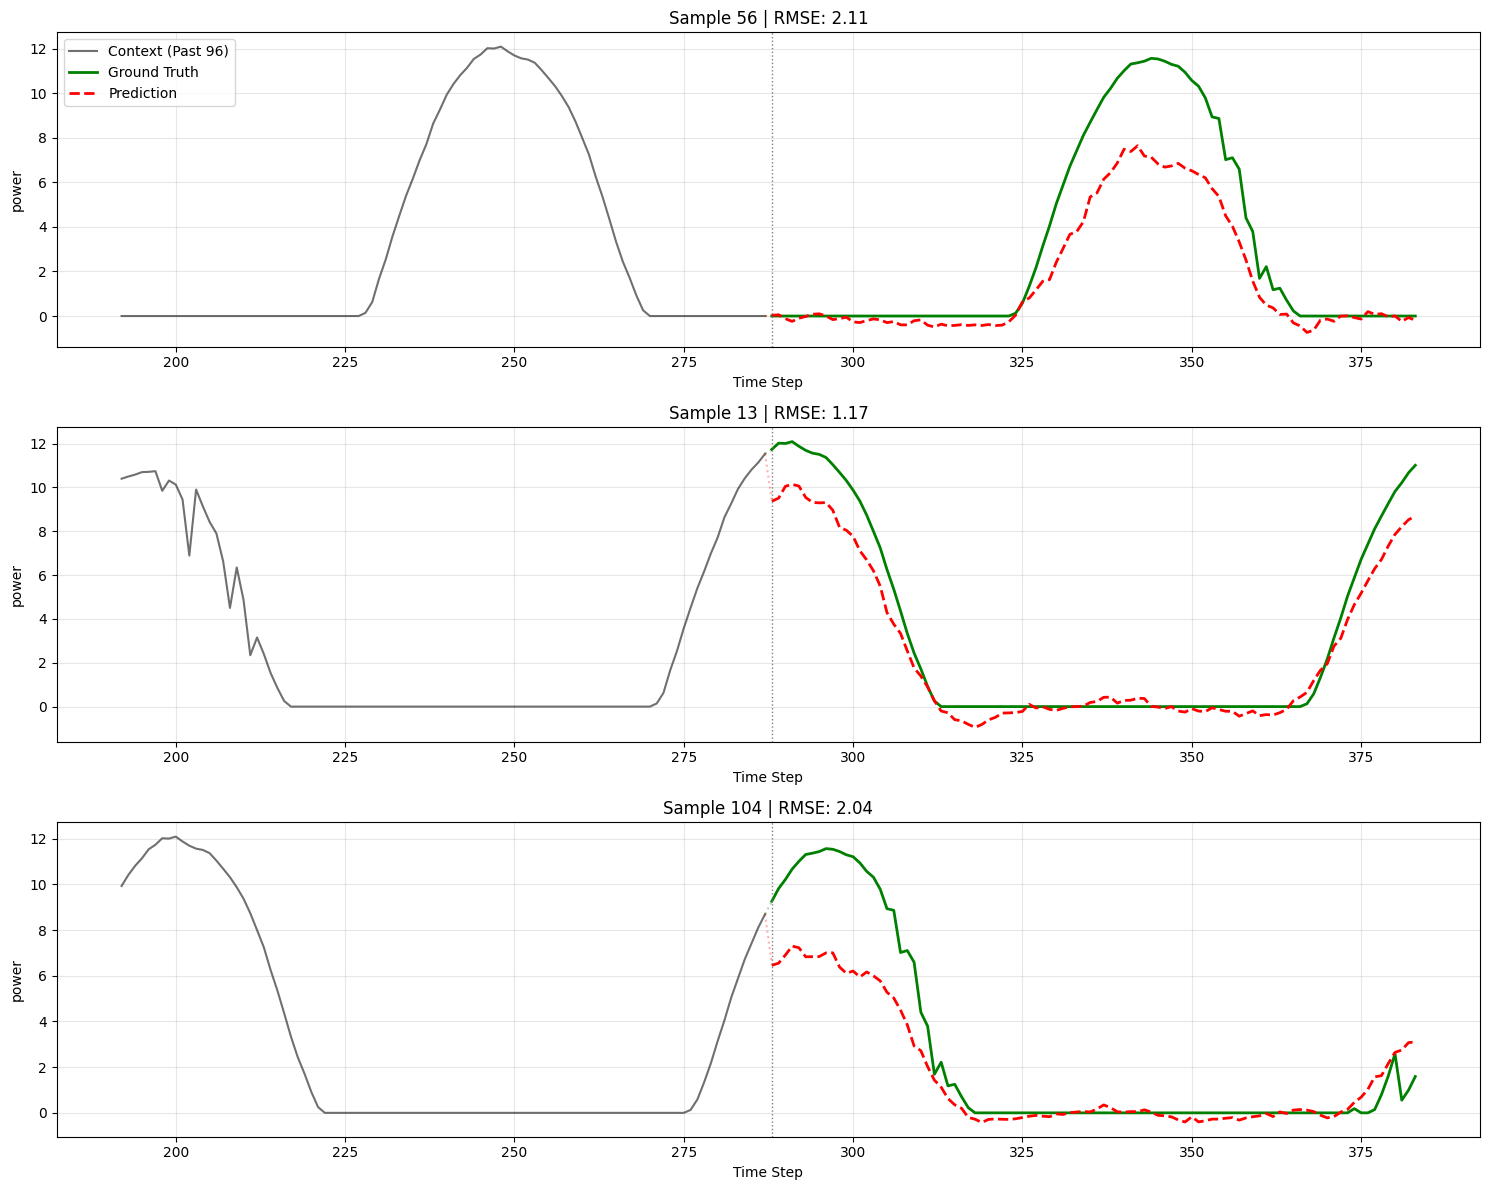

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_predictions(results, configs, fold_idx=0, num_samples=3, context_len=96):
    """
    Visualizes the model's behavior focusing on the transition from past to future.
    
    Args:
        results: The list returned by run_rolling_cv
        configs: Your MambaModelConfigs object
        fold_idx: Which fold to visualize (0 for the first fold)
        num_samples: How many random examples to show
        context_len: How many steps of the 'Past' to show (default 96)
    """
    # 1. Retrieve the correct fold data
    fold_data = results[fold_idx]
    model = fold_data['model']
    test_loader = fold_data['test_loader']
    device = configs.device
    
    # 2. Get a single batch from the test loader
    batch = next(iter(test_loader))
    x_past, y_future, x_future = batch
    
    # Move to device for inference
    x_past   = x_past.to(device)
    x_future = x_future.to(device)
    y_future = y_future.to(device)
    
    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        preds = model(x_past, x_future, None) 
        
    # 4. Move back to CPU for plotting
    x_past   = x_past.cpu().numpy()
    y_future = y_future.cpu().numpy()
    preds    = preds.cpu().numpy()
    
    # 5. Identify the Index of the Target Column
    target_idx = configs.PAST_INPUT_COLS.index(configs.TARGET_COL[0])
    
    # 6. Pick Random Indices
    total_batch_size = x_past.shape[0]
    n_plot = min(num_samples, total_batch_size)
    sample_indices = np.random.choice(range(total_batch_size), size=n_plot, replace=False)
    
    # 7. Plotting Loop
    plt.figure(figsize=(15, 4 * n_plot)) # Slightly taller for better detail
    
    # Dimensions for time axes
    seq_len = x_past.shape[1]
    pred_len = y_future.shape[1]
    
    # Calculate start index for the past (ensure we don't go negative)
    past_start_idx = max(0, seq_len - context_len)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(n_plot, 1, i+1)
        
        # --- A. Extract Data (Sliced) ---
        # Get only the last 'context_len' steps of history
        past_history = x_past[idx, past_start_idx:, target_idx] 
        true_future  = y_future[idx, :, 0]
        pred_future  = preds[idx, :, 0]
        
        # --- B. Create Time Axes ---
        # We keep the X-axis continuous relative to the total sequence
        t_past = np.arange(past_start_idx, seq_len)
        t_future = np.arange(seq_len, seq_len + pred_len)
        
        # --- C. Plot ---
        # Plot Past
        plt.plot(t_past, past_history, label='Context (Past 96)', color='#333333', alpha=0.7)
        
        # Plot Future (Ground Truth)
        plt.plot(t_future, true_future, label='Ground Truth', color='green', linewidth=2)
        
        # Plot Prediction
        plt.plot(t_future, pred_future, label='Prediction', color='red', linestyle='--', linewidth=2)
        
        # --- D. Styling & Connectors ---
        # Draw a vertical line at "Present Time"
        plt.axvline(x=seq_len, color='gray', linestyle=':', linewidth=1)
        
        # Optional: Connect the last past point to the first future point for visual continuity
        # This helps see if there is a "jump" at the prediction start
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], true_future[0]], 
                 color='green', linestyle=':', alpha=0.3)
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], pred_future[0]], 
                 color='red', linestyle=':', alpha=0.3)

        # Metrics
        sample_rmse = np.sqrt(np.mean((true_future - pred_future)**2))
        plt.title(f"Sample {idx} | RMSE: {sample_rmse:.2f}")
        plt.ylabel(configs.TARGET_COL[0])
        plt.xlabel("Time Step")
        plt.grid(True, alpha=0.3)
        
        if i == 0:
            plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# --- Usage ---
visualize_predictions(phys_results, configs, fold_idx=0, num_samples=3, context_len=96)


---

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdaptivePhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,           
        t_idx,           
        k_ross=0.035,    
        gamma=0.004,     
        G_night_thr=5.0, 
        G_day_thr=10.0   
    ):
        super().__init__()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        self.G_night_thr = G_night_thr
        self.G_day_thr = G_day_thr

        # --- 1. FIXED PHYSICS CONSTANTS (Buffers) ---
        self.register_buffer('k_ross', torch.tensor(k_ross))
        self.register_buffer('gamma', torch.tensor(gamma))
        self.register_buffer('T_ref', torch.tensor(25.0)) 
        
        # --- 2. LEARNABLE WEIGHTS (Parameters) ---
        # We initialize s such that the initial weight is approx 1.0
        # weight = 1 / (2 * exp(s))
        # s=0.0 => weight=0.5. s=-0.7 => weight=1.0
        
        # Weight for Data Loss
        self.s_data = nn.Parameter(torch.tensor(-0.5)) 
        
        # Weight for Physics (Ross)
        self.s_phys = nn.Parameter(torch.tensor(-0.5))
        
        # Weight for "Hard Constraints" (Night + Bounds)
        # We group these because they represent "Absolute Truths"
        self.s_bound = nn.Parameter(torch.tensor(-1.0)) 

        self.mse = nn.MSELoss()

    def forward(self, preds, targets, inputs):
        preds_flat = preds.squeeze(-1)
        targets_flat = targets.squeeze(-1)
        
        G_irrad = inputs[:, :, self.g_idx] 
        T_amb = inputs[:, :, self.t_idx]   
        
        # --- A. Calculate Raw Losses ---
        
        # 1. Data Loss
        loss_data = self.mse(preds_flat, targets_flat)
        
        # 2. Night Loss
        night_mask = G_irrad < self.G_night_thr
        loss_night = torch.mean(preds_flat[night_mask]**2) if night_mask.any() else torch.tensor(0.0, device=preds.device)

        # 3. Physics Slack Loss (ReLU Upper Bound)
        day_mask = G_irrad > self.G_day_thr
        if day_mask.any():
            T_cell_proxy = T_amb[day_mask] + self.k_ross * G_irrad[day_mask]
            K_phys_limit = 1.0 - self.gamma * (T_cell_proxy - self.T_ref) + 0.05
            violation = F.relu(preds_flat[day_mask] - K_phys_limit)
            loss_phys = torch.mean(violation ** 2)
        else:
            loss_phys = torch.tensor(0.0, device=preds.device)
            
        # 4. Capacity & Non-Negativity
        loss_nonneg = torch.mean(F.relu(-preds_flat) ** 2)
        loss_cap = torch.mean(F.relu(preds_flat - 1.1) ** 2)
        
        # Combine hard constraints
        loss_constraints = loss_night + loss_nonneg + loss_cap

        # --- B. Apply Adaptive Weighting (Kendall's Method) ---
        # Formula: L_total = (Loss / 2*exp(s)) + s/2
        # This stops the "Infinite Confidence" crash.
        s_data_clamped = torch.clamp(self.s_data, min=-3.0)
        s_phys_clamped = torch.clamp(self.s_phys, min=-3.0)
        s_bound_clamped = torch.clamp(self.s_bound, min=-3.0)
        # 1. Data Component
        weighted_data = (loss_data / (2 * torch.exp(s_data_clamped))) + (s_data_clamped / 2)
        
        # 2. Physics Component
        weighted_phys = (loss_phys / (2 * torch.exp(s_phys_clamped))) + (s_phys_clamped / 2)
        
        # 3. Constraint Component
        weighted_bound = (loss_constraints / (2 * torch.exp(s_bound_clamped))) + (s_bound_clamped / 2)

        return weighted_data + weighted_phys + weighted_bound

In [46]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    # We look up where 'nwp_globalirrad' and 'nwp_temperature' are in the FUTURE columns
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        print(f"Physics Loss Configuration: Irradiance Index={idx_g}, Temp Index={idx_t}")
    except ValueError as e:
        print("Error: 'nwp_globalirrad' or 'nwp_temperature' not found in FUTURE_INPUT_COLS")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Physics Experiment Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        # Instantiate Model
        model = Model(configs).to(device)

        # --- 2. Instantiate Physics Loss ---
        criterion = AdaptivePhysicsGuidedLoss(
            g_idx=idx_g,
            t_idx=idx_t
        ).to(device)

        # IMPORTANT: Now we optimize BOTH Model AND Loss Weights
        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), 
            lr=1e-3
        )

        # Define MAX weights
        MAX_W_PHYS = 0.5
        MAX_W_NIGHT = 0.5
        
        for epoch in range(configs.epochs): # Adjust EPOCHS as needed
            # Curriculum: Start with 0 physics, ramp up to Max by epoch 10
            progress = min(1.0, epoch / 10.0)
            # Update weights in the criterion dynamically
            progress = (epoch + 1) / configs.epochs
            criterion.w_phys = MAX_W_PHYS * progress
            criterion.w_night = MAX_W_NIGHT * progress
            criterion.w_nonneg = 0.5 * progress # Non-negativity is safe to ramp too
            
            # Use the NEW training function
            train_loss = train_one_epoch_physics(model, train_loader, optimizer, criterion)
            
            # Use the NEW evaluation function
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        # Final Evaluation
        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [47]:
class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 288        # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature','K_PV', 'power',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature']
        self.TARGET_COL = ['power']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 128     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 2 
        self.batch_size = 128
        self.epochs = 50
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()

In [48]:
# 1. Setup Configs (Same as before)
configs = MambaModelConfigs()
# 2. Run the Physics Experiment
print("Starting Physics-Guided Training...")
phys_results_adaptive, phys_history_adaptive = run_physics_experiment(df, configs)

# 3. Compare Results
print(f"Physics RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Physics-Guided Training...
Physics Loss Configuration: Irradiance Index=0, Temp Index=1

=== Physics Experiment Fold 1/2 ===
Epoch 002 | Train Loss=9.9751 | Val RMSE=2.9557
Epoch 004 | Train Loss=8.6207 | Val RMSE=2.9263
Epoch 006 | Train Loss=7.6051 | Val RMSE=2.9224
Epoch 008 | Train Loss=6.7813 | Val RMSE=2.9210
Epoch 010 | Train Loss=6.1016 | Val RMSE=2.9949
Epoch 012 | Train Loss=5.5470 | Val RMSE=3.0282
Epoch 014 | Train Loss=4.9676 | Val RMSE=3.0759
Epoch 016 | Train Loss=4.4297 | Val RMSE=3.1418
Epoch 018 | Train Loss=3.8958 | Val RMSE=3.1915
Epoch 020 | Train Loss=3.3718 | Val RMSE=3.2575
Epoch 022 | Train Loss=2.8705 | Val RMSE=3.2883
Epoch 024 | Train Loss=2.4039 | Val RMSE=3.3091
Epoch 026 | Train Loss=2.2517 | Val RMSE=3.4697
Epoch 028 | Train Loss=1.7276 | Val RMSE=3.3826
Epoch 030 | Train Loss=1.3070 | Val RMSE=3.3988
Epoch 032 | Train Loss=0.9568 | Val RMSE=3.4030
Epoch 034 | Train Loss=0.6391 | Val RMSE=3.4176
Epoch 036 | Train Loss=0.6351 | Val RMSE=3.4523
Ep

In [49]:
benchmark_results(phys_results_adaptive, df, configs)

Fold  | Model      | MAE (MW)   | RMSE (MW) 
--------------------------------------------------
1     | Mamba      | 22.6416     | 49.1460
      | NWP        | 20.4113     | 45.2294
      | Persist    | 22.7107     | 49.1905
--------------------------------------------------
2     | Mamba      | 152.4897     | 316.9215
      | NWP        | 39.1458     | 75.9935
      | Persist    | 41.4711     | 79.7875
--------------------------------------------------


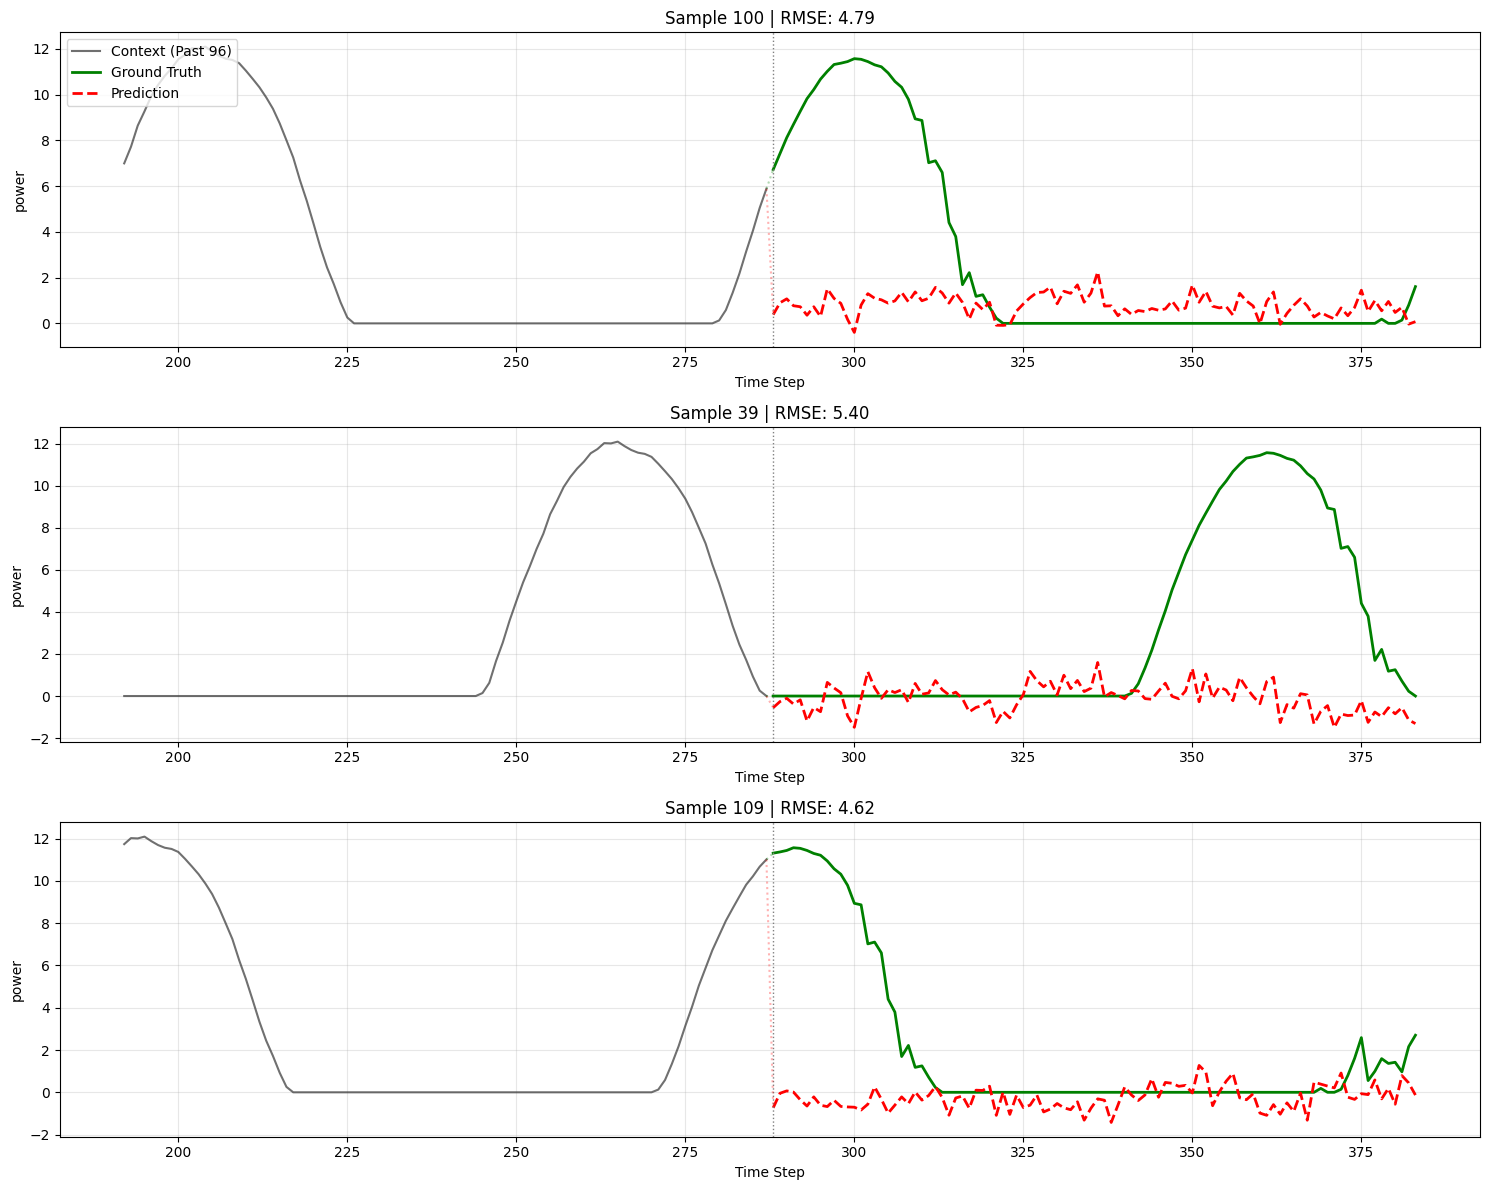

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_predictions(results, configs, fold_idx=0, num_samples=3, context_len=3*96):
    """
    Visualizes the model's behavior focusing on the transition from past to future.
    
    Args:
        results: The list returned by run_rolling_cv
        configs: Your MambaModelConfigs object
        fold_idx: Which fold to visualize (0 for the first fold)
        num_samples: How many random examples to show
        context_len: How many steps of the 'Past' to show (default 96)
    """
    # 1. Retrieve the correct fold data
    fold_data = results[fold_idx]
    model = fold_data['model']
    test_loader = fold_data['test_loader']
    device = configs.device
    
    # 2. Get a single batch from the test loader
    batch = next(iter(test_loader))
    x_past, y_future, x_future = batch
    
    # Move to device for inference
    x_past   = x_past.to(device)
    x_future = x_future.to(device)
    y_future = y_future.to(device)
    
    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        preds = model(x_past, x_future, None) 
        
    # 4. Move back to CPU for plotting
    x_past   = x_past.cpu().numpy()
    y_future = y_future.cpu().numpy()
    preds    = preds.cpu().numpy()
    
    # 5. Identify the Index of the Target Column
    target_idx = configs.PAST_INPUT_COLS.index(configs.TARGET_COL[0])
    
    # 6. Pick Random Indices
    total_batch_size = x_past.shape[0]
    n_plot = min(num_samples, total_batch_size)
    sample_indices = np.random.choice(range(total_batch_size), size=n_plot, replace=False)
    
    # 7. Plotting Loop
    plt.figure(figsize=(15, 4 * n_plot)) # Slightly taller for better detail
    
    # Dimensions for time axes
    seq_len = x_past.shape[1]
    pred_len = y_future.shape[1]
    
    # Calculate start index for the past (ensure we don't go negative)
    past_start_idx = max(0, seq_len - context_len)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(n_plot, 1, i+1)
        
        # --- A. Extract Data (Sliced) ---
        # Get only the last 'context_len' steps of history
        past_history = x_past[idx, past_start_idx:, target_idx] 
        true_future  = y_future[idx, :, 0]
        pred_future  = preds[idx, :, 0]
        
        # --- B. Create Time Axes ---
        # We keep the X-axis continuous relative to the total sequence
        t_past = np.arange(past_start_idx, seq_len)
        t_future = np.arange(seq_len, seq_len + pred_len)
        
        # --- C. Plot ---
        # Plot Past
        plt.plot(t_past, past_history, label='Context (Past 96)', color='#333333', alpha=0.7)
        
        # Plot Future (Ground Truth)
        plt.plot(t_future, true_future, label='Ground Truth', color='green', linewidth=2)
        
        # Plot Prediction
        plt.plot(t_future, pred_future, label='Prediction', color='red', linestyle='--', linewidth=2)
        
        # --- D. Styling & Connectors ---
        # Draw a vertical line at "Present Time"
        plt.axvline(x=seq_len, color='gray', linestyle=':', linewidth=1)
        
        # Optional: Connect the last past point to the first future point for visual continuity
        # This helps see if there is a "jump" at the prediction start
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], true_future[0]], 
                 color='green', linestyle=':', alpha=0.3)
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], pred_future[0]], 
                 color='red', linestyle=':', alpha=0.3)

        # Metrics
        sample_rmse = np.sqrt(np.mean((true_future - pred_future)**2))
        plt.title(f"Sample {idx} | RMSE: {sample_rmse:.2f}")
        plt.ylabel(configs.TARGET_COL[0])
        plt.xlabel("Time Step")
        plt.grid(True, alpha=0.3)
        
        if i == 0:
            plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# --- Usage ---
visualize_predictions(phys_results_adaptive, configs, fold_idx=0, num_samples=3, context_len=96)


-----

### Faiman Model

In [51]:

class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 1444    # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature', 'nwp_windspeed', 'lmd_totalirrad','lmd_temperature', 'K_CS', 'K_PV', 'power',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature', 'nwp_windspeed']
        self.TARGET_COL = ['power']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 64     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 4 
        self.batch_size = 128
        self.epochs = 50
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()



In [52]:
class AdaptivePhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,           
        t_idx,
        w_idx,           # <--- NEW: Index for Wind Speed
        gamma=0.004,     
        G_night_thr=5.0, 
        G_day_thr=10.0   
    ):
        super().__init__()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        self.w_idx = w_idx # Store wind index
        self.G_night_thr = G_night_thr
        self.G_day_thr = G_day_thr

        # --- PHYSICS PARAMETERS (Learnable but Constrained) ---
        # Faiman Model: T_c = T_amb + G / (U0 + U1 * Wind)
        # We make them learnable so the PINN fits your site specific cooling.
        
        # U0: Constant heat transfer (approx 25.0 for free standing)
        self.u0 = nn.Parameter(torch.tensor(25.0)) 
        
        # U1: Wind heat transfer (approx 6.84 for free standing)
        self.u1 = nn.Parameter(torch.tensor(6.8)) 

        self.register_buffer('gamma', torch.tensor(gamma))
        self.register_buffer('T_ref', torch.tensor(25.0)) 
        
        # --- ADAPTIVE WEIGHTS (Kendall's Method) ---
        # Initialize with -3.0 (high confidence start)
        self.s_data = nn.Parameter(torch.tensor(-3.0)) 
        self.s_phys = nn.Parameter(torch.tensor(-3.0))
        self.s_bound = nn.Parameter(torch.tensor(-3.0)) 

        self.mse = nn.MSELoss()

    def forward(self, preds, targets, inputs):
        preds_flat = preds.squeeze(-1)
        targets_flat = targets.squeeze(-1)
        
        # Extract Physics Inputs
        G_irrad = inputs[:, :, self.g_idx] 
        T_amb = inputs[:, :, self.t_idx]
        W_speed = inputs[:, :, self.w_idx] # <--- Extract Wind
        
        # --- 1. Data Loss ---
        loss_data = self.mse(preds_flat, targets_flat)
        
        # --- 2. Physics Loss (Faiman + Efficiency Limit) ---
        day_mask = G_irrad > self.G_day_thr
        
        if day_mask.any():
            # 1. Enforce physical constraints on U0 and U1 (Must be positive)
            # We use Softplus to ensure they never go negative during training
            u0_pos = F.softplus(self.u0)
            u1_pos = F.softplus(self.u1)
            
            # 2. Faiman Model for Cell Temp
            # T_c = T_amb + G / (U0 + U1 * Wind)
            cooling_factor = u0_pos + u1_pos * W_speed[day_mask]
            
            # Avoid division by zero (add epsilon)
            T_cell_proxy = T_amb[day_mask] + (G_irrad[day_mask] / (cooling_factor + 1e-5))
            
            # 3. Efficiency Derating Limit
            K_phys_limit = 1.0 - self.gamma * (T_cell_proxy - self.T_ref) + 0.05
            
            # 4. Slack Penalty (Upper Bound Only)
            violation = F.relu(preds_flat[day_mask] - K_phys_limit)
            loss_phys = torch.mean(violation ** 2)
        else:
            loss_phys = torch.tensor(0.0, device=preds.device)

        # --- 3. Boundaries ---
        night_mask = G_irrad < self.G_night_thr
        loss_night = torch.mean(preds_flat[night_mask]**2) if night_mask.any() else torch.tensor(0.0, device=preds.device)
        loss_nonneg = torch.mean(F.relu(-preds_flat) ** 2)
        loss_cap = torch.mean(F.relu(preds_flat - 1.1) ** 2)
        loss_constraints = loss_night + loss_nonneg + loss_cap

        # --- 4. Adaptive Weighting (Clamped) ---
        s_data_c = torch.clamp(self.s_data, min=-5.0, max=2.0)
        s_phys_c = torch.clamp(self.s_phys, min=-5.0, max=2.0)
        s_bound_c = torch.clamp(self.s_bound, min=-5.0, max=2.0)

        w_data = (loss_data / (2 * torch.exp(s_data_c))) + (s_data_c / 2)
        w_phys = (loss_phys / (2 * torch.exp(s_phys_c))) + (s_phys_c / 2)
        w_bound = (loss_constraints / (2 * torch.exp(s_bound_c))) + (s_bound_c / 2)

        return w_data + w_phys + w_bound

In [53]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        # FIX 1: Corrected string to match MambaModelConfigs ('nwp_windspeed')
        idx_w = configs.FUTURE_INPUT_COLS.index('nwp_windspeed') 
        print(f"Physics Config: G={idx_g}, T={idx_t}, Wind={idx_w}")
    except ValueError as e:
        print(f"Error finding columns in: {configs.FUTURE_INPUT_COLS}")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Physics Experiment Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        # Instantiate Model
        model = Model(configs).to(device)

        # --- 2. Instantiate Adaptive Physics Loss ---
        criterion = AdaptivePhysicsGuidedLoss(
            g_idx=idx_g, t_idx=idx_t, w_idx=idx_w
        ).to(device)

        # FIX 2: Add criterion.parameters() to optimizer!
        # This allows the model to learn 's' (weights) and 'u0/u1' (Faiman physics)
        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), 
            lr=1e-3
        )
        
        # FIX 3: Removed Manual Weight Ramping
        # We do not set criterion.w_phys anymore. The Adaptive Loss handles this via 's_phys'.
        
        for epoch in range(configs.epochs):
            
            # Use the training function
            train_loss = train_one_epoch_physics(model, train_loader, optimizer, criterion)
            
            # Use the evaluation function
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        # Final Evaluation
        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [54]:
# 1. Setup Configs (Same as before)

# 2. Run the Physics Experiment
print("Starting Physics-Guided Training...")
phys_results_adaptive, phys_history_adaptive = run_physics_experiment(df, configs)

# 3. Compare Results
print(f"Physics RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Physics-Guided Training...
Physics Config: G=0, T=1, Wind=2

=== Physics Experiment Fold 1/4 ===
Epoch 002 | Train Loss=143.6094 | Val RMSE=3.2342
Epoch 004 | Train Loss=131.2891 | Val RMSE=3.2254
Epoch 006 | Train Loss=121.2262 | Val RMSE=3.2119
Epoch 008 | Train Loss=112.5839 | Val RMSE=3.2134
Epoch 010 | Train Loss=104.8738 | Val RMSE=3.2444
Epoch 012 | Train Loss=98.1848 | Val RMSE=3.2317
Epoch 014 | Train Loss=92.0203 | Val RMSE=3.2155
Epoch 016 | Train Loss=87.9943 | Val RMSE=3.3138
Epoch 018 | Train Loss=934.0067 | Val RMSE=12.2947
Epoch 020 | Train Loss=129.1293 | Val RMSE=3.7219
Epoch 022 | Train Loss=88.0933 | Val RMSE=3.5257
Epoch 024 | Train Loss=80.5938 | Val RMSE=3.4710
Epoch 026 | Train Loss=76.4619 | Val RMSE=3.4738
Epoch 028 | Train Loss=73.9729 | Val RMSE=3.4388
Epoch 030 | Train Loss=72.0198 | Val RMSE=3.4705
Epoch 032 | Train Loss=70.2835 | Val RMSE=3.4154
Epoch 034 | Train Loss=68.7593 | Val RMSE=3.4562
Epoch 036 | Train Loss=67.2573 | Val RMSE=3.4562
Epoc

------

## Dynamic Learning 

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdaptivePhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,           
        t_idx,           
        k_ross=0.035,    
        gamma=0.004,    
        G_night_thr=5.0, 
        G_day_thr=10.0   
    ):
        super().__init__()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        self.G_night_thr = G_night_thr
        self.G_day_thr = G_day_thr

        # --- 1. PHYSICAL PARAMETERS (Learnable per paper Highlight 4) ---
        # [cite_start]"The key physical parameters (efficiency and temp coeff) are learnable" [cite: 475]
        self.gamma = nn.Parameter(torch.tensor(gamma))      # Equivalent to 'alpha' in paper
        self.k_ross = nn.Parameter(torch.tensor(k_ross))    # Learnable Ross coefficient
        self.register_buffer('T_ref', torch.tensor(25.0)) 
        
        # --- 2. UNCERTAINTY WEIGHTS (Kendall's Method) ---
        # We add a specific weight for the new Consistency Loss
        
        self.s_data = nn.Parameter(torch.tensor(-0.5))        # Weight for Data Loss
        self.s_phys = nn.Parameter(torch.tensor(-0.5))        # Weight for Slack/Upper Bound
        self.s_bound = nn.Parameter(torch.tensor(-1.0))       # Weight for Hard Constraints

        self.mse = nn.MSELoss()

    def forward(self, preds, targets, inputs):
        preds_flat = preds.squeeze(-1)
        targets_flat = targets.squeeze(-1)
        
        G_irrad = inputs[:, :, self.g_idx] 
        T_amb = inputs[:, :, self.t_idx]   
        
        # --- A. Calculate Raw Losses ---
        
        # 1. Data Loss (Empirical)
        loss_data = self.mse(preds_flat, targets_flat)
        
        # 2. Night Loss (Hard Constraint)
        night_mask = G_irrad < self.G_night_thr
        loss_night = torch.mean(preds_flat[night_mask]**2) if night_mask.any() else torch.tensor(0.0, device=preds.device)

        # 3. Physics Losses (Daytime Only)
        day_mask = G_irrad > self.G_day_thr
        
        if day_mask.any():
            # Calculate Cell Temp using learnable k_ross
            T_cell_proxy = T_amb[day_mask] + self.k_ross * G_irrad[day_mask]
            
            # --- Consistency Loss (L_c) ---
            # [cite_start]Eq 13: P = eta * G * (1 + alpha * (T - T_ref)) [cite: 369]
            # We use (1 - gamma * delta_T) because gamma is typically positive in code (approx 0.004) 
            # while alpha is negative in physics (-0.004).
            efficiency_proxy = (1 - self.gamma * (T_cell_proxy - self.T_ref))
            P_phys = G_irrad[day_mask] * efficiency_proxy 

            # [cite_start]Force prediction to match the physical equation [cite: 455]
            loss_consistency = self.mse(preds_flat[day_mask], P_phys)

            # --- Slack Loss (L_p upper bound) ---
            # A looser constraint ensuring we don't exceed theoretical max + margin
            K_phys_limit = 1.0 - self.gamma * (T_cell_proxy - self.T_ref) + 0.05
            violation = F.relu(preds_flat[day_mask] - K_phys_limit)
            loss_phys = torch.mean(violation ** 2)
            
        else:
            # Handle cases with no daylight (e.g., night batches)
            loss_phys = torch.tensor(0.0, device=preds.device)
            loss_consistency = torch.tensor(0.0, device=preds.device)
            
        # 4. Capacity & Non-Negativity
        loss_nonneg = torch.mean(F.relu(-preds_flat) ** 2)
        loss_cap = torch.mean(F.relu(preds_flat - 1.1) ** 2)
        
        loss_constraints = loss_night + loss_nonneg + loss_cap

        # --- B. Apply Adaptive Weighting (Kendall's Method) ---
        # Clamp to prevent numerical instability
        s_data_c = torch.clamp(self.s_data, min=-3.0)
        s_phys_c = torch.clamp(self.s_phys, min=-3.0)
        s_bound_c = torch.clamp(self.s_bound, min=-3.0)

        # Apply formula: (Loss / 2e^s) + s/2
        w_data = (loss_data / (2 * torch.exp(s_data_c))) + (s_data_c / 2)
        w_phys = (loss_phys / (2 * torch.exp(s_phys_c))) + (s_phys_c / 2)
        w_bound = (loss_constraints / (2 * torch.exp(s_bound_c))) + (s_bound_c / 2)

        return w_data + w_phys  + w_bound

In [56]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    # We look up where 'nwp_globalirrad' and 'nwp_temperature' are in the FUTURE columns
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        print(f"Physics Loss Configuration: Irradiance Index={idx_g}, Temp Index={idx_t}")
    except ValueError as e:
        print("Error: 'nwp_globalirrad' or 'nwp_temperature' not found in FUTURE_INPUT_COLS")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Physics Experiment Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        # Instantiate Model
        model = Model(configs).to(device)

        # --- 2. Instantiate Physics Loss ---
        criterion = AdaptivePhysicsGuidedLoss(
            g_idx=idx_g,
            t_idx=idx_t
        ).to(device)

        # IMPORTANT: Now we optimize BOTH Model AND Loss Weights
        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), 
            lr=1e-3
        )

        # Define MAX weights
        MAX_W_PHYS = 0.5
        MAX_W_NIGHT = 0.5
        
        for epoch in range(configs.epochs): # Adjust EPOCHS as needed
            # Curriculum: Start with 0 physics, ramp up to Max by epoch 10
            progress = min(1.0, epoch / 10.0)
            # Update weights in the criterion dynamically
            progress = (epoch + 1) / configs.epochs
            criterion.w_phys = MAX_W_PHYS * progress
            criterion.w_night = MAX_W_NIGHT * progress
            criterion.w_nonneg = 0.5 * progress # Non-negativity is safe to ramp too
            
            # Use the NEW training function
            train_loss = train_one_epoch_physics(model, train_loader, optimizer, criterion)
            
            # Use the NEW evaluation function
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        # Final Evaluation
        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [57]:
class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 1444    # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature', 'lmd_totalirrad','lmd_temperature', 'K_CS', 'K_PV', 'power',
       'hour_sin','hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_temperature']
        self.TARGET_COL = ['power']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 25  
        self.n_embed = 64     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 2         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.2

        self.n_splits = 4 
        self.batch_size = 128
        self.epochs = 50
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = MambaModelConfigs()

In [58]:
# 1. Setup Configs (Same as before)
configs = MambaModelConfigs()
# 2. Run the Physics Experiment
print("Starting Physics-Guided Training...")
phys_results_adaptive_dynamic, phys_history_adaptive_dynamic = run_physics_experiment(df, configs)

# 3. Compare Results
print(f"Physics RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Physics-Guided Training...
Physics Loss Configuration: Irradiance Index=0, Temp Index=1

=== Physics Experiment Fold 1/4 ===
Epoch 002 | Train Loss=10.9630 | Val RMSE=3.2413
Epoch 004 | Train Loss=9.2760 | Val RMSE=3.0647
Epoch 006 | Train Loss=8.5063 | Val RMSE=2.9574
Epoch 008 | Train Loss=7.8962 | Val RMSE=2.9495
Epoch 010 | Train Loss=7.3666 | Val RMSE=2.9690
Epoch 012 | Train Loss=6.9280 | Val RMSE=3.0192
Epoch 014 | Train Loss=24.7340 | Val RMSE=3.2981
Epoch 016 | Train Loss=6.9841 | Val RMSE=3.2010
Epoch 018 | Train Loss=6.3756 | Val RMSE=3.1375
Epoch 020 | Train Loss=6.0044 | Val RMSE=3.1401
Epoch 022 | Train Loss=5.7163 | Val RMSE=3.1526
Epoch 024 | Train Loss=5.4568 | Val RMSE=3.1715
Epoch 026 | Train Loss=5.2179 | Val RMSE=3.1903
Epoch 028 | Train Loss=4.9863 | Val RMSE=3.1639
Epoch 030 | Train Loss=4.7848 | Val RMSE=3.2064
Epoch 032 | Train Loss=4.6318 | Val RMSE=3.1971
Epoch 034 | Train Loss=4.4354 | Val RMSE=3.2472
Epoch 036 | Train Loss=4.3137 | Val RMSE=3.2176


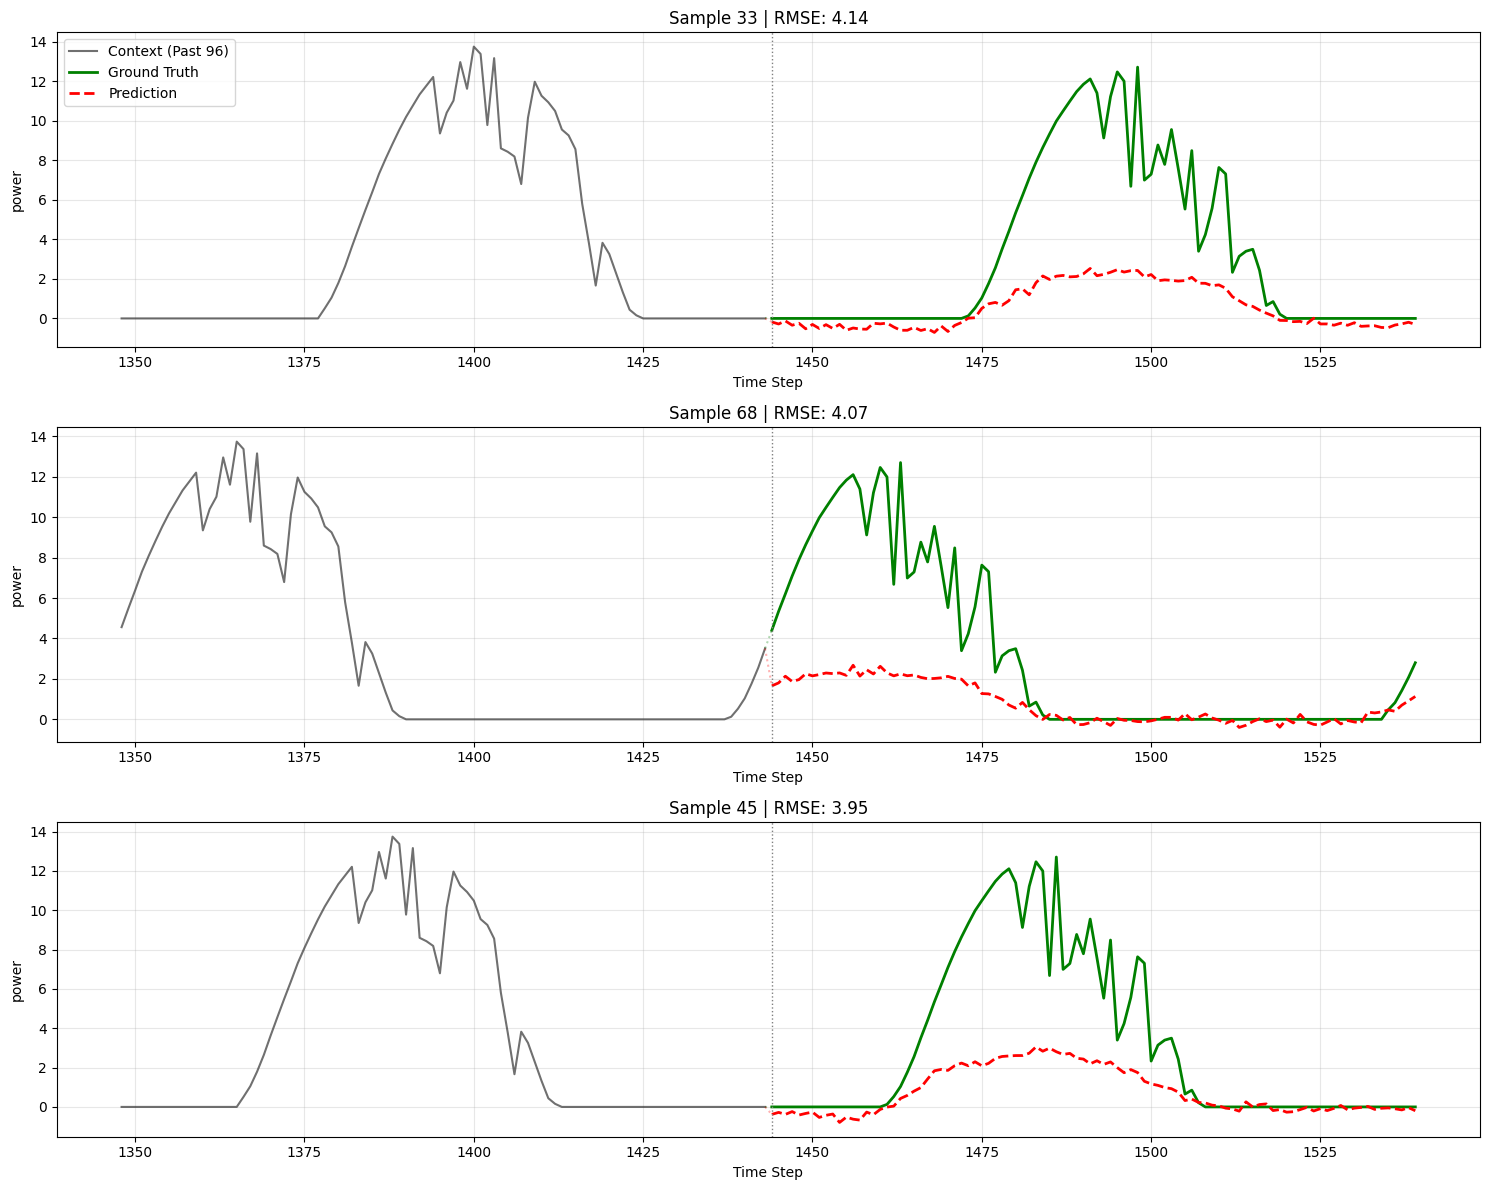

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_predictions(results, configs, fold_idx=0, num_samples=3, context_len=3*96):
    """
    Visualizes the model's behavior focusing on the transition from past to future.
    
    Args:
        results: The list returned by run_rolling_cv
        configs: Your MambaModelConfigs object
        fold_idx: Which fold to visualize (0 for the first fold)
        num_samples: How many random examples to show
        context_len: How many steps of the 'Past' to show (default 96)
    """
    # 1. Retrieve the correct fold data
    fold_data = results[fold_idx]
    model = fold_data['model']
    test_loader = fold_data['test_loader']
    device = configs.device
    
    # 2. Get a single batch from the test loader
    batch = next(iter(test_loader))
    x_past, y_future, x_future = batch
    
    # Move to device for inference
    x_past   = x_past.to(device)
    x_future = x_future.to(device)
    y_future = y_future.to(device)
    
    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        preds = model(x_past, x_future, None) 
        
    # 4. Move back to CPU for plotting
    x_past   = x_past.cpu().numpy()
    y_future = y_future.cpu().numpy()
    preds    = preds.cpu().numpy()
    
    # 5. Identify the Index of the Target Column
    target_idx = configs.PAST_INPUT_COLS.index(configs.TARGET_COL[0])
    
    # 6. Pick Random Indices
    total_batch_size = x_past.shape[0]
    n_plot = min(num_samples, total_batch_size)
    sample_indices = np.random.choice(range(total_batch_size), size=n_plot, replace=False)
    
    # 7. Plotting Loop
    plt.figure(figsize=(15, 4 * n_plot)) # Slightly taller for better detail
    
    # Dimensions for time axes
    seq_len = x_past.shape[1]
    pred_len = y_future.shape[1]
    
    # Calculate start index for the past (ensure we don't go negative)
    past_start_idx = max(0, seq_len - context_len)
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(n_plot, 1, i+1)
        
        # --- A. Extract Data (Sliced) ---
        # Get only the last 'context_len' steps of history
        past_history = x_past[idx, past_start_idx:, target_idx] 
        true_future  = y_future[idx, :, 0]
        pred_future  = preds[idx, :, 0]
        
        # --- B. Create Time Axes ---
        # We keep the X-axis continuous relative to the total sequence
        t_past = np.arange(past_start_idx, seq_len)
        t_future = np.arange(seq_len, seq_len + pred_len)
        
        # --- C. Plot ---
        # Plot Past
        plt.plot(t_past, past_history, label='Context (Past 96)', color='#333333', alpha=0.7)
        
        # Plot Future (Ground Truth)
        plt.plot(t_future, true_future, label='Ground Truth', color='green', linewidth=2)
        
        # Plot Prediction
        plt.plot(t_future, pred_future, label='Prediction', color='red', linestyle='--', linewidth=2)
        
        # --- D. Styling & Connectors ---
        # Draw a vertical line at "Present Time"
        plt.axvline(x=seq_len, color='gray', linestyle=':', linewidth=1)
        
        # Optional: Connect the last past point to the first future point for visual continuity
        # This helps see if there is a "jump" at the prediction start
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], true_future[0]], 
                 color='green', linestyle=':', alpha=0.3)
        plt.plot([t_past[-1], t_future[0]], [past_history[-1], pred_future[0]], 
                 color='red', linestyle=':', alpha=0.3)

        # Metrics
        sample_rmse = np.sqrt(np.mean((true_future - pred_future)**2))
        plt.title(f"Sample {idx} | RMSE: {sample_rmse:.2f}")
        plt.ylabel(configs.TARGET_COL[0])
        plt.xlabel("Time Step")
        plt.grid(True, alpha=0.3)
        
        if i == 0:
            plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# --- Usage ---
visualize_predictions(phys_results_adaptive_dynamic, configs, fold_idx=0, num_samples=3, context_len=96)
